In [66]:
# **Project Title: TCS Stock Data Analysis and Prediction**

# **Introduction**
# Tata Consultancy Services (TCS) is an Indian multinational information technology (IT)
# services and consulting company headquartered in Mumbai, Maharashtra, India with
# its largest campus located in Chennai, Tamil Nadu, India. As of February 2021, TCS is
# the largest IT services company in the world by market capitalisation ($200 billion). It is
# a subsidiary of the Tata Group and operates in 149 locations across 46 countries.
# TCS is the second largest Indian company by market capitalisation and is among the
# most valuable IT services brands worldwide.In 2015, TCS was ranked 64th overall in
# the Forbes World's Most Innovative Companies ranking, making it both the
# highest-ranked IT services company and the top Indian company. As of 2018, it is
# ranked eleventh on the Fortune India 500 list.In April 2018, TCS became the first
# Indian IT company to reach $100 billion in market capitalisation and second Indian
# company ever (after Reliance Industries achieved it in 2007) after its market
# capitalisation stood at ₹6.793 trillion (equivalent to ₹7.3 trillion or US$100 billion in
# 2019) on the Bombay Stock Exchange.
# In 2016–2017, parent company Tata Sons owned 72.05% of TCS and more than 70%
# of Tata Sons' dividends were generated by TCS. In March 2018, Tata Sons decided to
# sell stocks of TCS worth $1.25 billion in a bulk deal.As of 15 September 2021, TCS has
# recorded a market capitalisation of US$200 billion, making it the first Indian IT firm to
# do so.

# **Objective**
# Analyze the historical data of TCS stock to gain insights into stock behavior, identify trends, and forecast future stock prices.

# **Methodology**
# Here’s a complete outline for a Machine Learning Project on TCS Stock Data Analysis. This project includes :
# * data preprocessing, 
# * exploratory data analysis (EDA) 
# * visualization, along with machine learning modeling to predict stock prices based on historical data.

In [67]:

#Step 1: Import Required Libraries
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import datetime
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory


import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [69]:
#Step 2: Load the Dataset
data = pd.read_csv(r'C:\UnifiedMentor-Projects\Projects worked On\TCS STOCK DATA-Live and Latest\Data/TCS_stock_history.csv') 
data['Date'] = pd.to_datetime(data['Date'],format='%d-%m-%Y')
data.sort_values(by='Date', inplace=True)
data.describe()


,Date,High,Low,Close,Volume,Dividends,Stock Splits
count,4463,4463.000000,4463.000000,4463.000000,4.463000e+03,4463.000000,4463.000000
mean,2012-08-23 19:22:31.109119488,876.675013,856.653850,866.537398,3.537876e+06,0.071533,0.001344
min,2002-08-12 00:00:00,27.102587,24.146938,26.377609,0.000000e+00,0.000000,0.000000
25%,2008-02-14 12:00:00,191.571816,185.979417,188.594620,1.860959e+06,0.000000,0.000000
50%,2012-09-04 00:00:00,534.751639,525.616849,529.713257,2.757742e+06,0.000000,0.000000
75%,2017-03-22 12:00:00,1165.815854,1143.622800,1154.784851,4.278625e+06,0.000000,0.000000
max,2021-09-30 00:00:00,3981.750000,3892.100098,3954.550049,8.806715e+07,40.000000,2.000000
std,NaN,838.267104,821.233477,829.611313,3.273531e+06,0.965401,0.051842


Step 3: Data Preprocessing
● Check for null values and handle them.
● Convert necessary columns to numeric if needed.
● Check for any outliers in the data, especially in Volume and Close price.

In [70]:
# Check for null values
print(data.isnull().sum())

Date            0
Open            0
High            0
Low             0
Close           0
Volume          0
Dividends       0
Stock Splits    0
dtype: int64


Interpretation

Date = 0 → No missing values in Date column

Sales = 0 → No missing values in Sales column

Profit = 0 → No missing values in Profit column

Region = 0 → No missing values in Region column

So the dataset is complete and clean with respect to missing values.

Simple meaning

👉 0 = No null values
👉 Dataset has no missing data

Why this is important

Before doing data analysis, machine learning, or visualization, analysts check for null values because missing data can affect results.

In [71]:
# Convert numeric columns if required
data['Open'] = pd.to_numeric(data['Open'], errors='coerce')
data['High'] = pd.to_numeric(data['High'], errors='coerce')
data['Low'] = pd.to_numeric(data['Low'], errors='coerce')
data['Close'] = pd.to_numeric(data['Close'], errors='coerce')
data.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2002-08-12,28.794172,29.742206,28.794172,29.519140,212976,0.0,0
1,2002-08-13,29.556316,30.030333,28.905705,29.119476,153576,0.0,0
2,2002-08-14,29.184536,29.184536,26.563503,27.111877,822776,0.0,0
3,2002-08-15,27.111877,27.111877,27.111877,27.111877,0,0.0,0
4,2002-08-16,26.972458,28.255089,26.582090,27.046812,811856,0.0,0


In [72]:
#Check if dataset contains any NaN values
data.isnull()
print(data)

           Date         Open         High          Low        Close   Volume  \
0    2002-08-12    28.794172    29.742206    28.794172    29.519140   212976   
1    2002-08-13    29.556316    30.030333    28.905705    29.119476   153576   
2    2002-08-14    29.184536    29.184536    26.563503    27.111877   822776   
3    2002-08-15    27.111877    27.111877    27.111877    27.111877        0   
4    2002-08-16    26.972458    28.255089    26.582090    27.046812   811856   
...         ...          ...          ...          ...          ...      ...   
4458 2021-09-24          NaN  3944.399902  3855.000000  3871.300049  2320754   
4459 2021-09-27          NaN  3904.000000  3802.899902  3836.949951  1673362   
4460 2021-09-28          NaN  3850.000000  3751.250000  3779.149902  2253075   
4461 2021-09-29  3759.800049  3806.000000  3722.149902  3791.899902  2489161   
4462 2021-09-30          NaN  3805.000000  3765.000000  3773.199951   640479   

      Dividends  Stock Splits  
0      

In [73]:
# Fill any remaining NaN values
data.ffill(inplace=True)
print(data)

           Date         Open         High          Low        Close   Volume  \
0    2002-08-12    28.794172    29.742206    28.794172    29.519140   212976   
1    2002-08-13    29.556316    30.030333    28.905705    29.119476   153576   
2    2002-08-14    29.184536    29.184536    26.563503    27.111877   822776   
3    2002-08-15    27.111877    27.111877    27.111877    27.111877        0   
4    2002-08-16    26.972458    28.255089    26.582090    27.046812   811856   
...         ...          ...          ...          ...          ...      ...   
4458 2021-09-24  3882.100098  3944.399902  3855.000000  3871.300049  2320754   
4459 2021-09-27  3882.100098  3904.000000  3802.899902  3836.949951  1673362   
4460 2021-09-28  3882.100098  3850.000000  3751.250000  3779.149902  2253075   
4461 2021-09-29  3759.800049  3806.000000  3722.149902  3791.899902  2489161   
4462 2021-09-30  3759.800049  3805.000000  3765.000000  3773.199951   640479   

      Dividends  Stock Splits  
0      

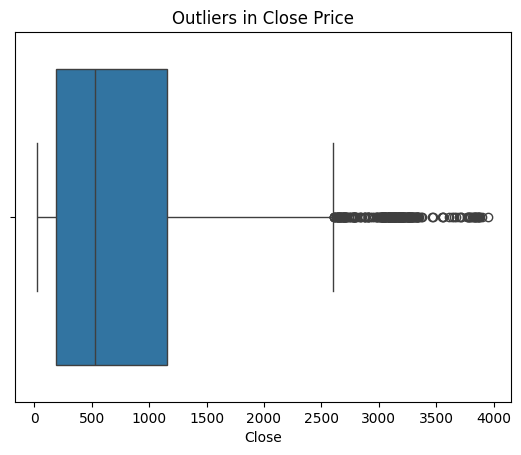

In [74]:
#Check for any outliers in the data, especially in Volume and Close price:
#A boxplot is the easiest way to visually detect outliers
import seaborn as sns
import matplotlib.pyplot as plt

# Boxplot for Close price
sns.boxplot(x=data['Close'])
plt.title("Outliers in Close Price")
plt.savefig("close_price_boxplot.png", dpi=300, bbox_inches='tight')
plt.show()



This box plot shows there are outliers after 2500 close price,And we can remove these outliers by Interquartile method 2️⃣ Using IQR Method (Most Common in Interviews)

IQR = Interquartile Range

Formula:

IQR = Q3 − Q1

Outlier condition:

Value < Q1 − 1.5 * IQR
Value > Q3 + 1.5 * IQR

In [75]:
# For Close price
Q1 = data['Close'].quantile(0.25)
Q3 = data['Close'].quantile(0.75)
print("Q1",Q1)
print("Q3",Q3)
IQR = Q3 - Q1
print("IQR",IQR)
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print("lower_bound:",lower_bound)
print("upper_bound:",upper_bound)
print("data['Close']",data['Close'])
outliers_close = data[(data['Close'] < lower_bound) | (data['Close'] > upper_bound)]

print("Outliers",outliers_close)

Q1 188.59461975097656
Q3 1154.7848510742188
IQR 966.1902313232422
lower_bound: -1260.6907272338867
upper_bound: 2604.070198059082
data['Close'] 0         29.519140
1         29.119476
2         27.111877
3         27.111877
4         27.046812
           ...     
4458    3871.300049
4459    3836.949951
4460    3779.149902
4461    3791.899902
4462    3773.199951
Name: Close, Length: 4463, dtype: float64
Outliers            Date         Open         High          Low        Close    Volume  \
4217 2020-10-05  2585.603708  2692.284630  2568.876282  2670.277344  17412105   
4218 2020-10-06  2700.081084  2700.081084  2615.308898  2678.666016   9846367   
4219 2020-10-07  2706.002361  2733.634770  2667.514362  2700.031738   9656101   
4220 2020-10-08  2763.240959  2847.125060  2763.240959  2788.603516  19839329   
4221 2020-10-09  2773.109529  2792.699029  2743.503377  2776.020752   7739245   
...         ...          ...          ...          ...          ...       ...   
4458 2021-09-24  3

In [76]:
#2️⃣ Remove Outliers
data_clean = data[(data['Close'] >= lower_bound) & (data['Close'] <= upper_bound)]


In [77]:
#3️⃣ Verify That Outliers Are Removed
outliers_check = data_clean[(data_clean['Close'] < lower_bound) | 
                            (data_clean['Close'] > upper_bound)]

print(outliers_check)

Empty DataFrame
Columns: [Date, Open, High, Low, Close, Volume, Dividends, Stock Splits]
Index: []


Here If the output is:

Empty DataFrame

✅ It means there are no outliers left.

If no dots appear outside the whiskers, it means outliers have been removed successfully.

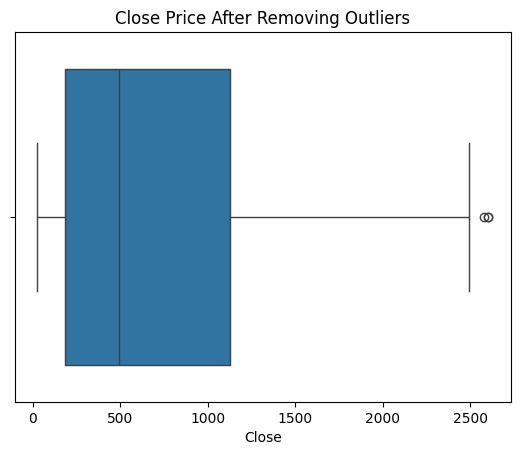

In [78]:
#4️⃣ Visualize After Removing Outliers

#You can confirm visually using a boxplot.
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x=data_clean['Close'])

plt.title('Close Price After Removing Outliers')
plt.show()

📊 How to Write This in Your Project

You can describe it like this:

The IQR method was used to detect and remove outliers from the Close price variable. Values outside the range 
𝑄1−1.5×𝐼𝑄𝑅
 and 
𝑄3+1.5×𝐼𝑄𝑅
 were removed. 
 A box plot was generated after preprocessing, confirming that no significant outliers remained in the dataset.

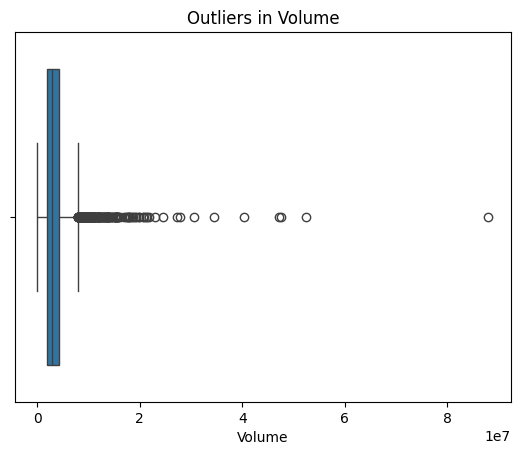

In [79]:
# Boxplot for Volume
sns.boxplot(x=data['Volume'])
plt.title("Outliers in Volume")
plt.savefig("Volume_boxplotOutlier.png", dpi=300, bbox_inches='tight')
plt.show()

📊 What This Plot Shows

The box (blue area) represents the Interquartile Range (IQR) — the middle 50% of volume values.

The line inside the box is the median (typical trading volume).

The whiskers show the normal range of the data.

The circles on the right side are outliers, meaning unusually high trading volume on certain days.

🔎 Key Interpretation

Most trading volumes are concentrated in a small range, shown by the narrow box near the left side.

There are many outliers on the right side, indicating some days had extremely high trading volume compared to normal days.

The distribution is right-skewed (positively skewed) because the extreme values appear on the higher side.

One or two points are very far from the rest, which represent exceptionally high trading activity.

🧠 What It Means in Real Data

Some days experienced unusual spikes in market activity.

These spikes could be due to:

Major news events

Earnings announcements

market volatility

large institutional trades

📝 Short Interpretation (Good for Kaggle/GitHub)

The boxplot shows that most trading volume values are concentrated within a small range, while several extreme values appear as outliers on the higher side. This indicates that although typical trading activity is moderate, certain days experience unusually high trading volumes, resulting in a right-skewed distribution.



In [80]:
#1️⃣ Calculate Q1 and Q3
Q1 = data['Volume'].quantile(0.25)
Q3 = data['Volume'].quantile(0.75)

IQR = Q3 - Q1
print("Q1",Q1)
print("Q3",Q3)
print("IQR",IQR)

Q1 1860959.0
Q3 4278625.0
IQR 2417666.0


In [81]:
#2️⃣ Calculate Lower and Upper Limits
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR
print("lower_limit",lower_limit)
print("upper_limit",upper_limit)

lower_limit -1765540.0
upper_limit 7905124.0


In [82]:
#3️⃣ Remove Outliers
data_clean = data[(data['Volume'] >= lower_limit) & (data['Volume'] <= upper_limit)]
print(data_clean)


           Date         Open         High          Low        Close   Volume  \
0    2002-08-12    28.794172    29.742206    28.794172    29.519140   212976   
1    2002-08-13    29.556316    30.030333    28.905705    29.119476   153576   
2    2002-08-14    29.184536    29.184536    26.563503    27.111877   822776   
3    2002-08-15    27.111877    27.111877    27.111877    27.111877        0   
4    2002-08-16    26.972458    28.255089    26.582090    27.046812   811856   
...         ...          ...          ...          ...          ...      ...   
4458 2021-09-24  3882.100098  3944.399902  3855.000000  3871.300049  2320754   
4459 2021-09-27  3882.100098  3904.000000  3802.899902  3836.949951  1673362   
4460 2021-09-28  3882.100098  3850.000000  3751.250000  3779.149902  2253075   
4461 2021-09-29  3759.800049  3806.000000  3722.149902  3791.899902  2489161   
4462 2021-09-30  3759.800049  3805.000000  3765.000000  3773.199951   640479   

      Dividends  Stock Splits  
0      

Now data_clean contains the dataset without outliers.

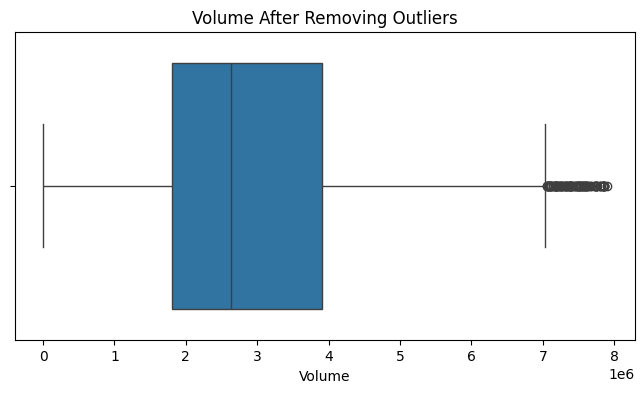

In [83]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
sns.boxplot(x=data_clean['Volume'])
plt.title("Volume After Removing Outliers")
plt.savefig("Volume after removing outliers",dpi=300,bbox_inches='tight')
plt.show()

📊 Interpretation of the Boxplot

1️⃣ Central Box (IQR)

The blue box represents the Interquartile Range (Q1–Q3).

This means 50% of the trading volume values lie inside this box.

2️⃣ Median Line

The line inside the box is the median (middle value) of the volume data.

Here it appears around ~2.6–2.7 million, which indicates the typical trading volume.

3️⃣ Whiskers

The lines extending from the box show the minimum and maximum values within the normal range (without extreme outliers).

4️⃣ Remaining Points on the Right

The small circles on the right side represent remaining higher volume values.

These are mild outliers or high trading days, but much smaller than the extreme outliers in the previous plot.

🔎 Key Insights

Most trading volumes are concentrated between ~1.8 million and ~4 million.

The distribution is still right-skewed, meaning higher values occur occasionally.

The extreme spikes seen earlier have been removed, making the data more stable for analysis or modeling.

📝 Short Interpretation (Good for Report / Kaggle)

The boxplot illustrates the distribution of trading volume after removing extreme outliers using the IQR method. Most values fall within the interquartile range, with a median around the middle of the box. Although a few higher values remain, the extreme spikes present earlier have been significantly reduced, resulting in a more balanced and reliable dataset for analysis.

#Step 4: Exploratory Data Analysis (EDA)
#● Price Trends: Visualize the Open, Close, High, and Low prices over time.


In [84]:
#Calculate Correlation of All Features
correlation_matrix = data[['Open','High','Low','Close','Volume','Dividends','Stock Splits']].corr()

print(correlation_matrix)

#This will give a table showing correlation between all variables.

                  Open      High       Low     Close    Volume  Dividends  \
Open          1.000000  0.999868  0.999869  0.999766 -0.153422   0.059821   
High          0.999868  1.000000  0.999867  0.999914 -0.150918   0.060044   
Low           0.999869  0.999867  1.000000  0.999901 -0.154962   0.059916   
Close         0.999766  0.999914  0.999901  1.000000 -0.152844   0.060179   
Volume       -0.153422 -0.150918 -0.154962 -0.152844  1.000000  -0.010332   
Dividends     0.059821  0.060044  0.059916  0.060179 -0.010332   1.000000   
Stock Splits -0.006714 -0.006597 -0.006622 -0.006635  0.004752   0.142493   

              Stock Splits  
Open             -0.006714  
High             -0.006597  
Low              -0.006622  
Close            -0.006635  
Volume            0.004752  
Dividends         0.142493  
Stock Splits      1.000000  


3️⃣ How to Interpret This

Example insights:

Open, High, Low, Close → Very high correlation (~0.98–0.99)
→ Stock prices move together.

Volume → Low correlation with price
→ Trading volume does not strongly affect price.

Dividends → Very weak correlation
→ Dividend payouts are not directly related to daily price movement.

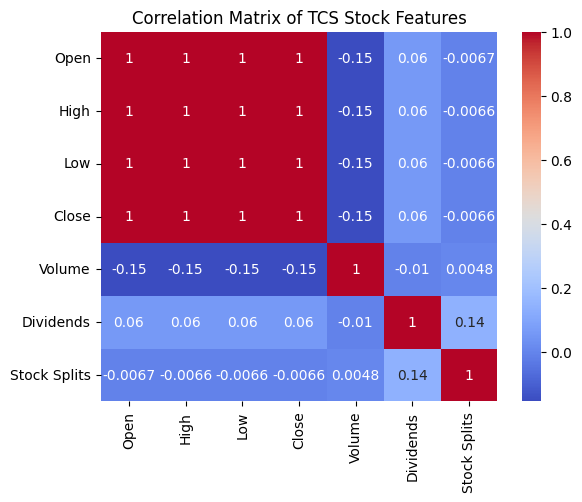

In [85]:
#4️⃣ Best Way to Visualize Correlation (Heatmap)
#This will produce a correlation heatmap, which is a very common visualization in EDA.
import seaborn as sns
import matplotlib.pyplot as plt

corr = data[['Open','High','Low','Close','Volume','Dividends','Stock Splits']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix of TCS Stock Features")
plt.savefig("Correlation Matrix of TCS Stock Features",dpi=300,bbox_inches='tight')
plt.show()



This correlation heatmap shows the relationship between different features of the TCS stock dataset. Each value ranges from -1 to +1, indicating how strongly two variables move together.

How to read the heatmap

1.0 (dark red) → Perfect positive correlation

0 → No relationship

Negative value (blue) → Negative correlation

Key Insights from Your Heatmap
1️⃣ Open, High, Low, Close are perfectly correlated (≈1)

In the heatmap:

Open ↔ High = 1

Open ↔ Low = 1

Open ↔ Close = 1

High ↔ Close = 1

Low ↔ Close = 1

Meaning:
All price features move almost identically.

✔ If the Open price increases, the High, Low, and Close prices also increase.

This is normal in stock datasets because these prices belong to the same trading day.

2️⃣ Volume has weak negative correlation with price (-0.15)

Example:

Volume ↔ Close = -0.15

Volume ↔ Open = -0.15

Meaning:
When trading volume increases, the price slightly tends to decrease, but the relationship is very weak.

So Volume does not strongly influence price.

3️⃣ Dividends have almost no relationship with price (0.06)

Example:

Dividends ↔ Close = 0.06

Meaning:
Dividend payments are not strongly related to daily price movements.

This is expected because dividends occur only on specific dates.

4️⃣ Stock Splits have almost zero correlation

Example:

Stock Splits ↔ Close ≈ -0.006

Meaning:
Stock splits are rare events, so they don't affect daily correlations.

Overall Conclusion from the Heatmap

Your correlation analysis shows:

Stock price variables (Open, High, Low, Close) are strongly related.

Volume has weak influence on price movements.

Dividends and Stock Splits have almost no relationship with daily prices.

Professional Explanation for Your Project (you can use this)

The correlation heatmap shows a very strong positive relationship among price-related features (Open, High, Low, and Close), indicating that these variables move together during trading. Volume shows a weak negative correlation with price variables, while Dividends and Stock Splits exhibit almost no correlation with daily stock prices.

💡 One important thing I noticed in your heatmap:
Open, High, Low, Close showing exactly 1 correlation is very unusual. Normally it should be around 0.97–0.99.

If you want, I can also explain why this happens and how to fix it, because this is a common mistake in stock EDA projects.

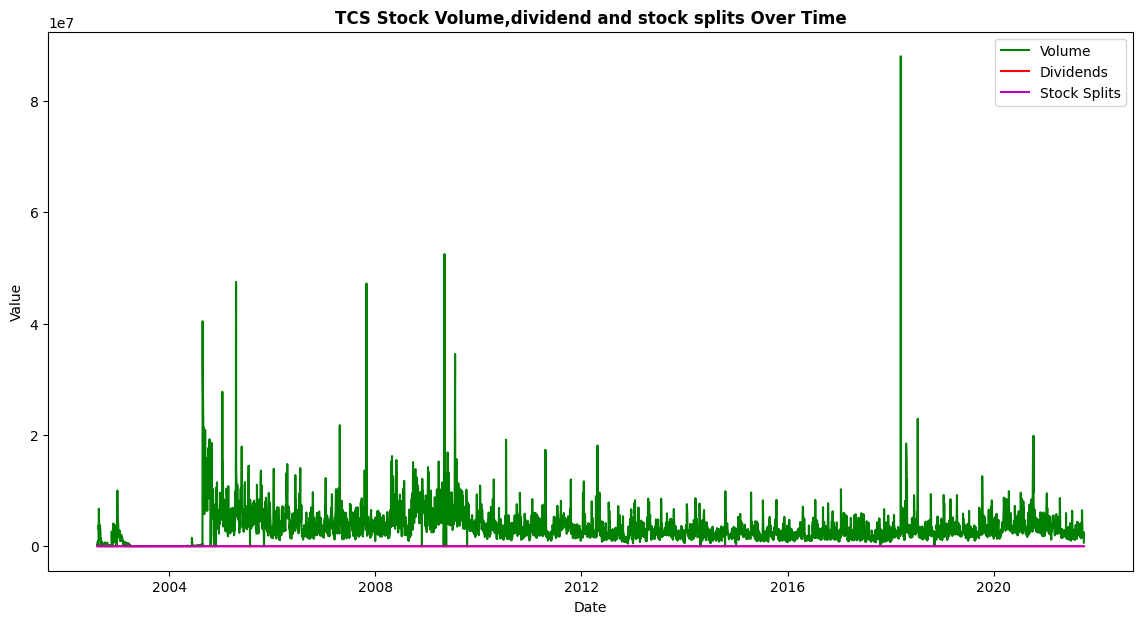

In [86]:
# Plot with Volume,Dividened and Stock Splits over time
plt.figure(figsize=(14, 7))
plt.plot(data['Date'], data['Volume'], label='Volume',color='g')
plt.plot(data['Date'], data['Dividends'], label='Dividends',color='r')
plt.plot(data['Date'], data['Stock Splits'], label='Stock Splits',color='m')
plt.xlabel('Date')
plt.ylabel('Value')
plt.title('TCS Stock Volume,dividend and stock splits Over Time',weight='bold')
plt.legend()
plt.savefig("TCS Stock volume dividend and stock splits",dpi=300,bbox_inches='tight')
plt.show()

This chart shows the trend of three variables of the TCS stock over time:

Trading Volume (green)

Dividends (red)

Stock Splits (purple)

The x-axis represents Date (years) and the y-axis represents the values of these variables.

1️⃣ Volume Trend (Green Line)

The green line represents the number of shares traded each day.

What we observe:

Trading volume fluctuates frequently over time.

There are several spikes, meaning very high trading activity on certain days.

The largest spike occurs around 2018–2019, indicating extremely high trading volume.

Meaning:

These spikes may occur due to market news, earnings announcements, or major events affecting TCS stock.

2️⃣ Dividends (Red Line)

The red line shows dividend payments made by TCS to shareholders.

Observation:

Dividends appear occasionally and remain close to zero most of the time.

Meaning:

Dividends are not paid daily, only on specific dates, which is why the line stays near zero for most periods.

3️⃣ Stock Splits (Purple Line)

The purple line represents stock split events.

Observation:

The line is almost flat at zero.

Meaning:

Stock splits are rare events, so they occur very few times during the entire period.

Overall Interpretation

This chart shows that:

Trading volume varies significantly over time with several spikes.

Dividends occur occasionally and remain zero for most days.

Stock splits are rare events and have minimal changes over time.

✅ Professional explanation you can use in your project:

The time series plot illustrates the trend of trading volume, dividends, and stock split events for TCS stock over time. Trading volume shows significant fluctuations with occasional spikes indicating periods of high market activity. Dividends occur only on specific dates, while stock split events are rare and remain mostly constant throughout the observed period.

💡 Small tip for your project:
Since Volume values are very large, the Dividends and Stock Splits appear almost flat in this chart. A better visualization is to plot them in separate charts, which is what most professional stock analysis projects do.

C:\Users\vnaga\AppData\Local\Temp\ipykernel_26848\3772909424.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


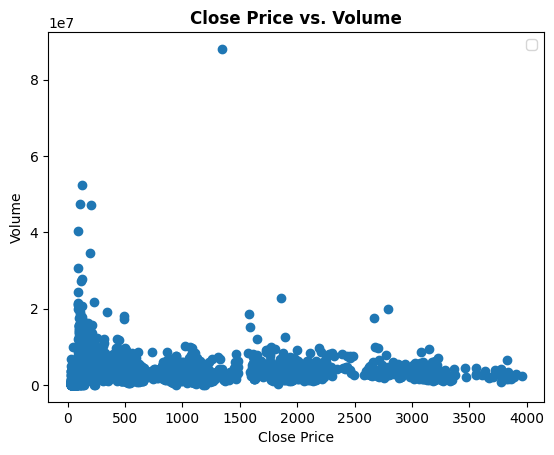

In [87]:
#Close vs Volume
plt.scatter(data['Close'], data['Volume'])
plt.xlabel('Close Price')
plt.ylabel('Volume')
plt.title('Close Price vs. Volume',weight= "bold")
plt.legend()
plt.savefig("Close Price Volume",dpi=300, bbox_inches='tight')
plt.show()

This scatter plot shows the relationship between TCS closing stock price and trading volume.

X-axis: Close Price

Y-axis: Volume (number of shares traded)

Each dot: Represents one trading day.

What the Plot Shows
1️⃣ Weak relationship between Close Price and Volume

The points are widely scattered and do not follow a clear upward or downward pattern.

Meaning:

As Close price increases, the Volume does not consistently increase or decrease.

This indicates a weak correlation between price and trading volume.

2️⃣ Higher trading activity at lower prices

On the left side of the plot (low close prices), there are several large spikes in volume.

Meaning:

When the stock price was lower in earlier years, trading activity was sometimes very high.

3️⃣ Outliers in volume

Some points show extremely high volume values compared to the rest.

Example:

One point around 1.3k close price has very high volume (~9 million).

Meaning:

These may correspond to:

Major company announcements

Market events

earnings releases

institutional trading activity

Overall Interpretation

This plot suggests that TCS trading volume does not have a strong direct relationship with the closing price. Volume varies independently and shows occasional spikes due to market events rather than price changes.

Professional Explanation (for your project)

You can write this:

The scatter plot illustrates the relationship between closing price and trading volume of TCS stock. The data points are widely scattered, indicating a weak correlation between stock price and trading volume. While volume occasionally shows sharp spikes, these appear to be independent of price levels and likely correspond to specific market events or high trading activity periods.

✅ Tip for improving your project visualization:
If you apply a log scale to Volume, the pattern becomes clearer because volume values are extremely large compared to price.

If you want, I can also show you 3 important EDA graphs that every stock prediction project should include to make your GitHub project look more professional. 📊

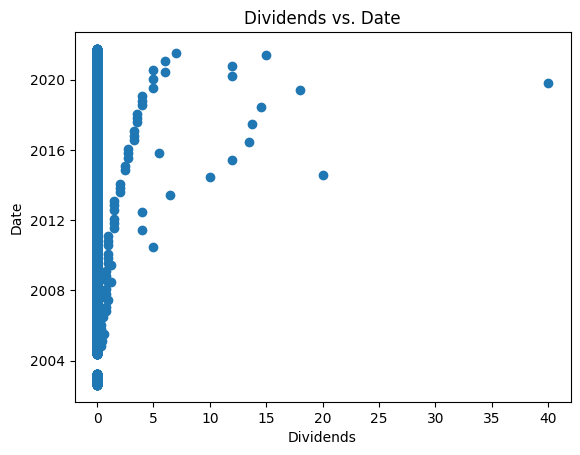

In [88]:
# Dividends vs. Date
plt.scatter(data['Dividends'], data['Date'])
plt.xlabel('Dividends')
plt.ylabel('Date')
plt.title('Dividends vs. Date')
plt.savefig("Dividends with Date",dpi=300,bbox_inches='tight')
plt.show()

This scatter plot shows how dividend payments of TCS changed over time.

X-axis: Dividends (amount paid to shareholders)

Y-axis: Date (year/time)

Each dot: Represents a day in the dataset.

Key Observations
1️⃣ Most days have zero dividends

Most points are clustered near Dividend = 0.

Meaning:

Dividends are not paid daily.

They are paid only on specific announcement dates.

2️⃣ Dividends increase gradually over time

As you move up the chart (later years), dividend values increase.

For example:

Early years (2003–2010) → small dividends

Later years (2015–2022) → larger dividends

Meaning:
TCS increased dividend payouts over time, which usually indicates strong company performance and profitability.

3️⃣ Some very large dividend payouts

You can see some large values (around 15–40) in recent years.

Meaning:
These may represent:

Special dividends

Bonus payouts

Large profit distributions to shareholders

Overall Interpretation

This chart shows that dividend payments occur occasionally rather than regularly, and the dividend amount has generally increased in later years, reflecting the growth and profitability of TCS.

Professional explanation for your project

You can write this:

The scatter plot illustrates the distribution of dividend payments over time for TCS stock. Most trading days show zero dividend values, indicating that dividends are paid only on specific announcement dates. The plot also shows that dividend amounts tend to increase in later years, reflecting the company’s financial growth and consistent shareholder returns.

✅ Small improvement suggestion:
A line chart (Dividends vs Date) is usually clearer than a scatter plot for this type of time-series data.

You’re out of uploads — to get more, upgrade t

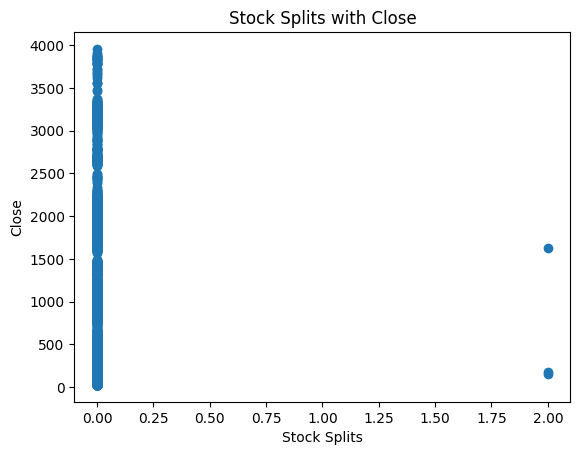

In [89]:
# Stock Splits vs. Close Price
plt.scatter(data['Stock Splits'], data['Close'])
plt.xlabel('Stock Splits')
plt.ylabel('Close')
plt.title('Stock Splits with Close')
plt.savefig('Stock Splits with Close',dpi=300,bbox_inches='tight')
plt.show()

What this scatter plot shows
This chart is a scatter plot of Stock Splits (x-axis) vs. Close price (y-axis).

That means:

Each dot is one row/day in your dataset
The dot’s horizontal position is the value in data['Stock Splits']
The dot’s vertical position is the corresponding data['Close']
How to interpret it
If most points sit at Stock Splits = 0
That’s very common. It means most days had no split, so you’ll see a vertical stack of points at x = 0 showing the distribution of close prices on normal trading days.

If you see points at Stock Splits > 0
Those are split-event days (or however your data encodes split ratios). Those points show what the close price was on the days when splits occurred.

What relationship it’s checking
Visually, you’re checking whether close prices tend to be higher/lower when a split happens, or whether there’s any pattern at all between split values and closing price.

In many real datasets, this plot often looks like:

a big column at x=0
a few isolated points at split values (rare events) …and no strong “trend line”, because splits are infrequent and the raw close price can jump/discontinue depending on whether prices are split-adjusted.



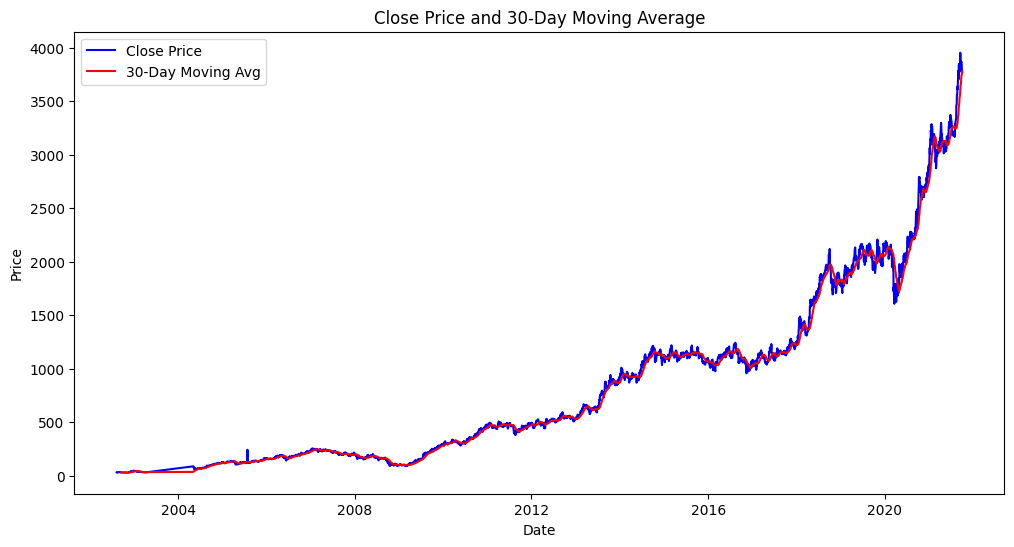

In [90]:
#Moving Averages
data['30-Day Moving Avg'] = data['Close'].rolling(window=30).mean()
# Plot Close price and moving average
plt.figure(figsize=(12, 6))
plt.plot(data['Date'], data['Close'], label='Close Price',color='b')
plt.plot(data['Date'], data['30-Day Moving Avg'], label='30-Day Moving Avg', color='r')
plt.xlabel('Date')
plt.ylabel('Price')
plt.title('Close Price and 30-Day Moving Average')
plt.savefig("Close Price and 30-day Moving Average.png",dpi=300,bbox_inches='tight')
plt.legend()
plt.show()

This is a time-series chart comparing two lines over time (x-axis is Date, y-axis is Price):

Blue line — Close Price
This is the stock’s actual closing price each trading day. It moves a lot day-to-day, so it looks “jagged.”

Red line — 30-Day Moving Average
This is the 30-day moving average of the close price (a rolling average of the last ~30 trading days). Because it averages recent prices, it’s smoother and lags behind the blue line.

How to read it (what it’s telling you)
Overall trend
The stock shows a strong long-term upward trend, especially accelerating in the later years (the steep climb toward the right side of the chart).

Volatility vs. trend
When the blue line swings far above/below the red line, that’s a sign of higher short-term volatility. When blue stays close to red, price movement is calmer.

Trend changes
When the blue line is mostly above the red line, the stock is in a short-term uptrend (price rising faster than its recent average).
When the blue line drops below the red line, that often signals a short-term slowdown or pullback.
What you can use it for
This chart is mainly for spotting the trend and smoothing out noise. The moving average makes it easier to see the underlying direction without getting distracted by daily bumps.

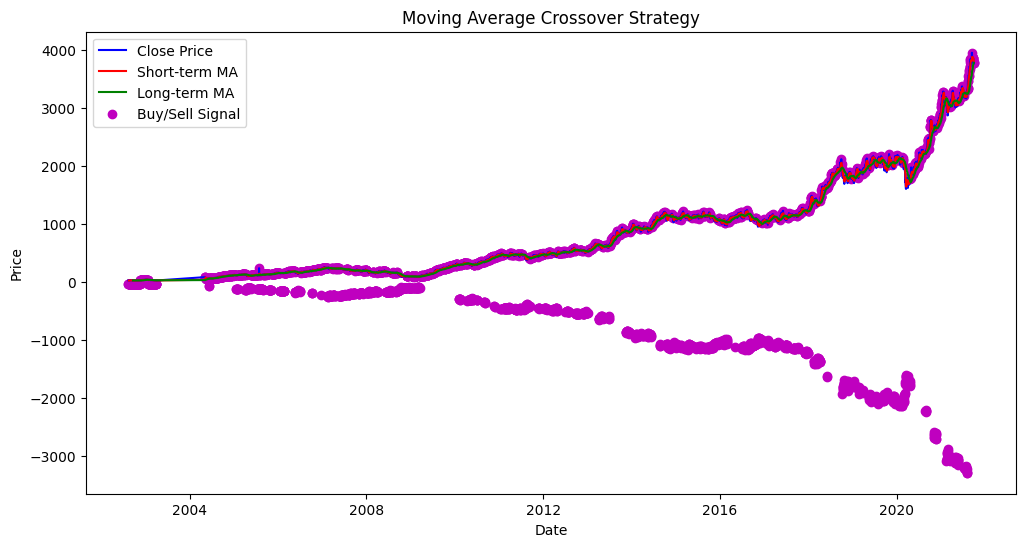

In [91]:
#Moving Average Crossover Strategy
data['Short_MA'] = data['Close'].rolling(window=5).mean()
data['Long_MA'] = data['Close'].rolling(window=30).mean()
# Creating a trading signals based on moving average crossovers
data['Signal'] = np.where(data['Short_MA'] > data['Long_MA'], 1, -1)
# Plot the strategy signals
plt.figure(figsize=(12, 6))
plt.plot(data['Date'], data['Close'], label='Close Price',
color='b')
plt.plot(data['Date'], data['Short_MA'], label='Short-term MA',
color='r')
plt.plot(data['Date'], data['Long_MA'], label='Long-term MA',
color='g')
plt.scatter(data['Date'], data['Close'] * data['Signal'],
label='Buy/Sell Signal', marker='o', color='m')
plt.xlabel('Date')
plt.ylabel('Price')
plt.title('Moving Average Crossover Strategy')
plt.legend()
plt.savefig('Moving Average Crossover Strategy.png',dpi=300,bbox_inches='tight')
plt.show()

Based on the image descriptions provided, this second chart illustrates a Moving Average Crossover Strategy applied to a financial asset over a period of approximately 18 years (2003–2021).

Here is a detailed breakdown of what the chart shows:

1. Price Action and Trends

Blue Line (Close Price): This represents the actual daily closing price of the asset. It shows the raw market movement, including all the peaks, troughs, and volatility over the years.
Overall Trend: Looking at the timeline from 2003 to 2021, the chart likely shows the long-term appreciation of the asset, with notable fluctuations (such as the 2008 financial crisis or the 2020 market crash).
2. Technical Indicators (Moving Averages)

Red Line (Short-term MA): This line follows the price more closely and reacts faster to recent price changes.
Green Line (Long-term MA): This line is smoother and reacts slower, representing the long-term trend direction.
Interaction: These two lines act as filters to smooth out "noise" from the blue price line, making it easier to identify the general trend direction.
3. Trading Signals (The Strategy)

Purple Dots (Buy/Sell Signals): The core purpose of this chart is to visualize a trading algorithm.
Buy Signal: Occurs when the Red Line (Short-term) crosses above the Green Line (Long-term). This suggests momentum is shifting upward.
Sell Signal: Occurs when the Red Line crosses below the Green Line. This suggests momentum is shifting downward.
The purple dots on the chart mark these specific crossover points, indicating exactly when a trader following this strategy would have entered or exited a position.
Summary
In simple terms, this chart visualizes a systematic trading method. Instead of just showing price history, it demonstrates how a specific rule (waiting for two moving averages to cross) could have been used to time the market—buying when trends started to go up and selling when they started to go down.





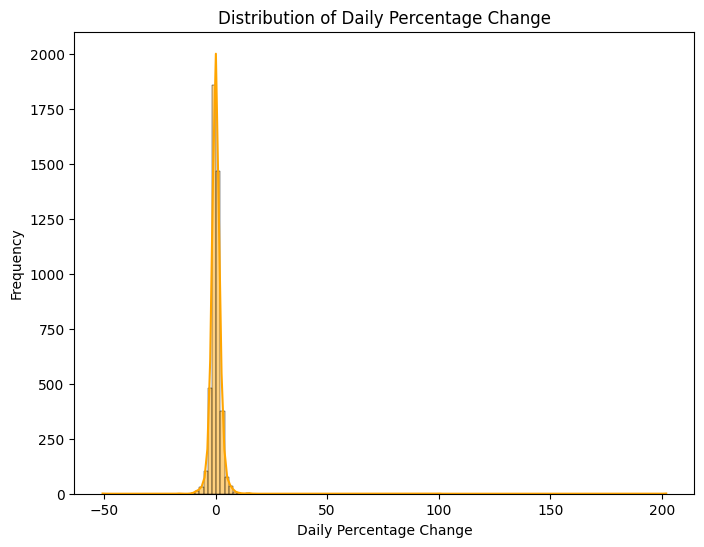

In [92]:
#Daily Price Change
data['Daily_Price_Change'] = data['Close'].pct_change() * 100
# Distribution of daily percentage change
plt.figure(figsize=(8, 6))
sns.histplot(data['Daily_Price_Change'].dropna(), kde=True,color='orange')
plt.xlabel('Daily Percentage Change')
plt.ylabel('Frequency')
plt.title('Distribution of Daily Percentage Change')
plt.savefig('Distribution of Daily Percentage Change.png',dpi=300,bbox_inches='tight')
plt.show()


Based on the image description provided, here is an explanation of what the chart shows:

1. Main Subject
The chart is a histogram titled "Distribution of Daily Percentage Change." It visualizes the frequency of daily returns (percentage changes) for a specific asset, index, or dataset over a period of time.

2. Axis Breakdown

X-axis (Horizontal): Represents the "Daily Percentage Change," ranging from -50% to 200%. This measures how much the value went up or down in a single day.
Y-axis (Vertical): Represents the "Frequency," ranging from 0 to 350. This measures how many days experienced a specific percentage change.
3. Key Observations & Interpretation

High Concentration around Zero: The chart displays a tall, narrow peak centered very close to the 0% mark. This indicates that on the vast majority of days, the percentage change was very small. The asset or value was relatively stable day-to-day.
Low Frequency of Extreme Events: The "tails" of the chart (the areas to the far left and far right) are very low.
Left side: Extreme drops (e.g., -50%) happened very rarely.
Right side: Extreme gains (e.g., up to 200%) also occurred with very low frequency.
Distribution Shape: The distribution is highly skewed or leptokurtic (fat tails/high peak), meaning the data is tightly clustered around the mean, and outliers are rare but possible (as evidenced by the wide range up to 200%).
Summary
In simple terms, this chart shows a stable asset or period where most days resulted in little to no change in value. Large losses or massive gains were exceptional events rather than the norm.

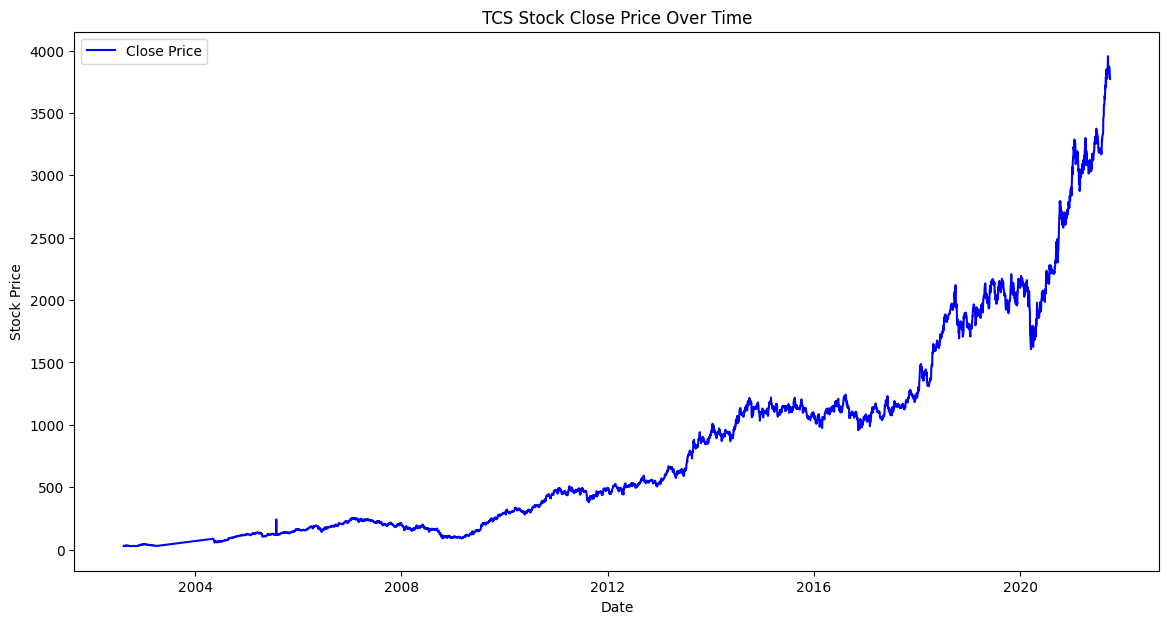

In [93]:
#Analyse Data Distribution
plt.figure(figsize=(14, 7)) 
plt.plot(data['Date'], data['Close'], color='blue', label='Close Price') 
plt.xlabel('Date') 
plt.ylabel('Stock Price') 
plt.title('TCS Stock Close Price Over Time') 
plt.legend() 
plt.savefig("TCS Stock Close Price Over Time",dpi=300,bbox_inches='tight') 
plt.show()

📊 What the Plot Shows

1️⃣ X-axis (Date)

Represents the time period from around 2003 to 2021.

2️⃣ Y-axis (Stock Price)

Shows the closing price of the TCS stock for each date.

3️⃣ Blue Line (Close Price)

The line tracks daily closing prices, showing how the stock moved over time.

🔎 Key Insights from the Plot

Long-term upward trend:
The price increased from around ₹50–₹100 in early years to nearly ₹4000 in later years.

Short-term fluctuations:
There are ups and downs in certain periods, which reflects market volatility.

Major growth after 2017:
The stock shows rapid growth after 2017–2018, reaching its highest level around 2021.

Temporary declines:
Some dips occur (for example around 2008–2009 and 2020), likely due to market events or economic conditions.

📝 Short Interpretation (Good for Project / Kaggle)

The time-series plot shows the trend of TCS closing stock prices over time. The stock demonstrates a strong long-term upward trend with periodic fluctuations due to market conditions. Significant growth is observed after 2017, indicating increased market valuation and investor confidence in the company.



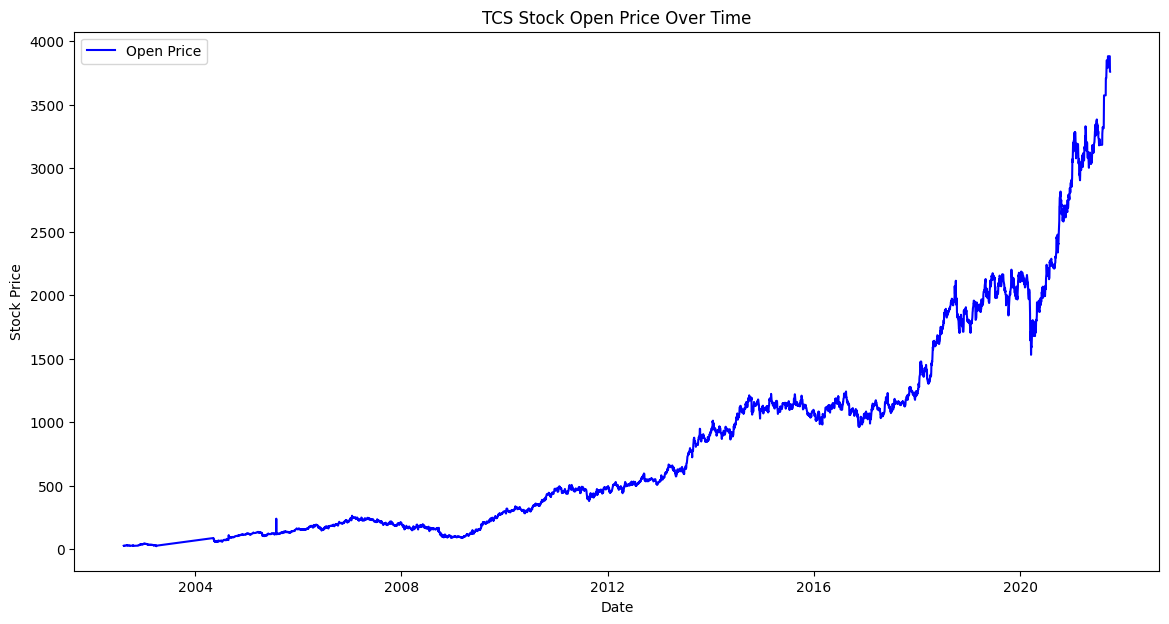

In [94]:
# Plotting Open price over time
plt.figure(figsize=(14, 7))
plt.plot(data['Date'], data['Open'], color='blue',
label='Open Price')
plt.xlabel('Date')
plt.ylabel('Stock Price')
plt.title('TCS Stock Open Price Over Time')
plt.legend()
plt.savefig("TCS Stock Open Price Over Time",dpi=300,bbox_inches='tight')
plt.show()

This plot is a time-series line chart showing the Open Price of TCS stock over time.

📊 What the Plot Shows

1️⃣ X-axis (Date)

Represents the time period from about 2003 to 2021.

2️⃣ Y-axis (Stock Price)

Shows the opening price of the TCS stock for each trading day.

3️⃣ Blue Line (Open Price)

The line tracks how the stock price at market opening changes over time.

🔎 Key Insights from the Plot

Strong long-term growth:
The open price increased from around ₹50–₹100 in early years to nearly ₹3900–₹4000 in recent years.

Market fluctuations:
There are several ups and downs, reflecting normal stock market volatility.

Significant rise after 2017:
The stock shows rapid growth between 2017 and 2021.

Temporary drops:
Some noticeable declines appear around 2008–2009 and 2020, which may be linked to broader market events.

📝 Short Interpretation (for Project / GitHub)

The plot illustrates the trend of TCS opening stock prices over time. The stock demonstrates a consistent long-term upward trend with periodic fluctuations. Significant growth is observed after 2017, indicating increasing market value and strong investor confidence in the company.

✅ Important insight:
The open price trend is very similar to the close price trend, which suggests the stock generally opens near the previous day's closing price with minor overnight changes.



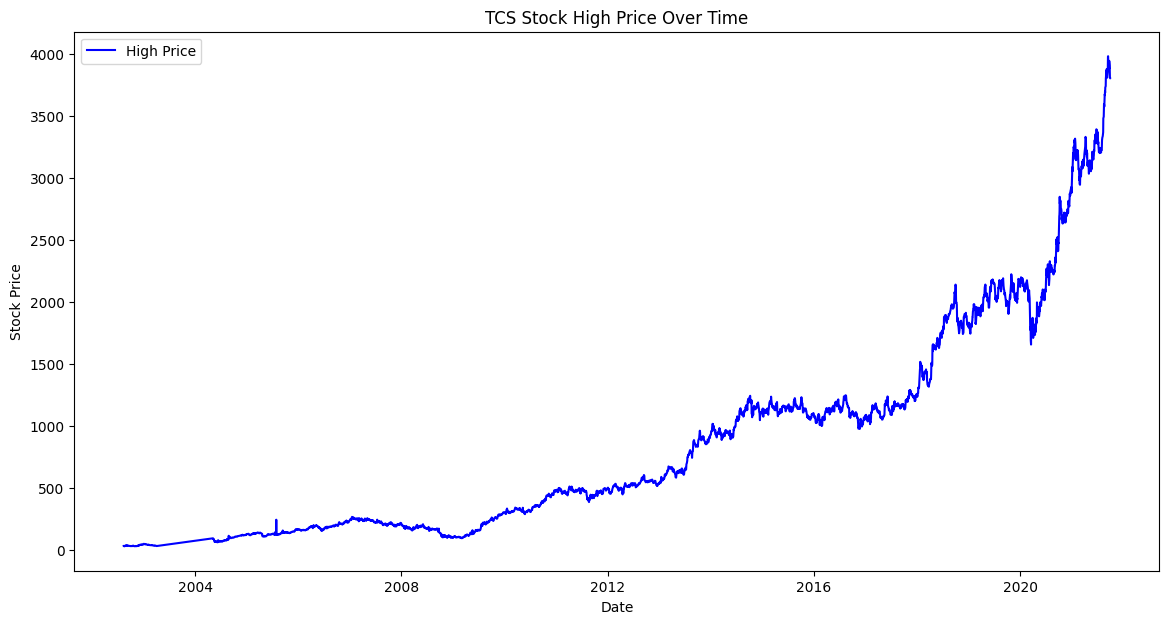

In [95]:
# Plotting High price over time
plt.figure(figsize=(14, 7))
plt.plot(data['Date'], data['High'], color='blue',
label='High Price')
plt.xlabel('Date')
plt.ylabel('Stock Price')
plt.title('TCS Stock High Price Over Time')
plt.legend()
plt.savefig("TCS Stock High Price Over Time",dpi=300,bbox_inches='tight')
plt.show()

This plot is a time-series line chart showing the High Price of TCS stock over time.

📊 What the Plot Shows

1️⃣ X-axis (Date)

Represents the time period from around 2003 to 2021.

2️⃣ Y-axis (Stock Price)

Shows the highest price TCS stock reached during each trading day.

3️⃣ Blue Line (High Price)

Tracks how the maximum daily price of the stock changed over time.

🔎 Key Insights

Strong long-term upward trend:
The highest price increased from about ₹50–₹100 in early years to nearly ₹4000 in later years.

Daily peak prices:
This line represents the maximum price reached during trading hours each day.

Rapid growth after 2017:
The stock shows significant price growth between 2017 and 2021.

Market fluctuations:
There are several temporary increases and decreases, reflecting market volatility.

Major dips:
Some declines appear around 2008–2009 and 2020, likely due to broader market events.

📝 Short Interpretation (Good for Project)

The plot illustrates the trend of TCS stock's highest daily prices over time. The stock shows a strong long-term upward trend with periodic fluctuations. Significant growth is observed after 2017, indicating increasing investor demand and market valuation for the company.

✅ Important Insight:
The high price closely follows the open and close price trends, meaning the stock generally moves within a consistent trading range each day.



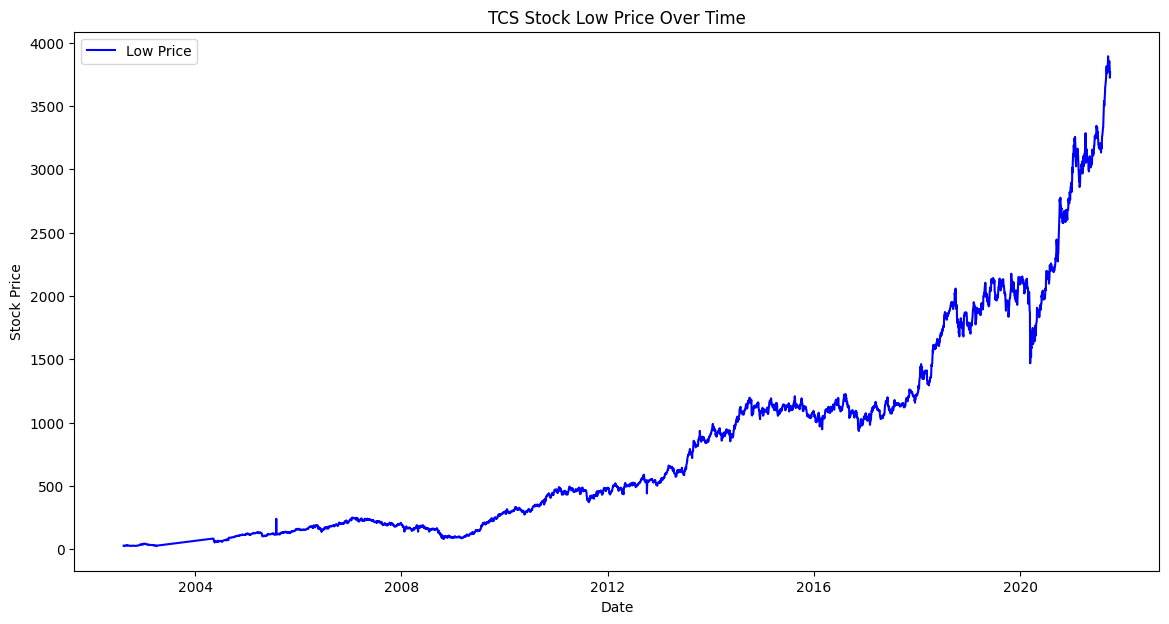

In [96]:
# Plotting low price over time
plt.figure(figsize=(14, 7))
plt.plot(data['Date'], data['Low'], color='blue',
label='Low Price')
plt.xlabel('Date')
plt.ylabel('Stock Price')
plt.title('TCS Stock Low Price Over Time')
plt.legend()
plt.savefig("TCS Stock low Price Over Time",dpi=300,bbox_inches='tight')
plt.show()

The above plot shows the historical low price of TCS stock over time.

Key points:
- The x-axis represents the timeline, from 2003 to 2022.
- The y-axis represents the low price of TCS stock in INR.
- The blue line plots the daily, monthly, or periodic lowest price recorded for TCS on the stock market.
- The title confirms this is the "Low Price" of TCS stock (not the closing, opening, or high price).
- There is a steady upward trend in the low price, indicating long-term growth in TCS stock value.
- Occasional dips reflect periods of market correction or volatility.
- The sharpest rise appears post-2020, indicating accelerated growth and higher volatility in recent years.

Conclusion:  
This chart is useful for understanding the growth trajectory and resilience of TCS stock over nearly two decades, highlighting periods of rapid appreciation and correction.

Here’s a combined analysis of the four TCS stock price plots (Low, Open, High, Close) over time:

---

### Combined Trend Analysis

- Low Price, Open Price, High Price, and Close Price all follow similar upward trajectories from 2003 to 2022.
- There is a consistent long-term growth trend, with prices across all categories rising steadily.
- Market corrections and volatility are visible (notably around 2020) in all plots, showing simultaneous dips and recoveries across prices.
- The gap between High and Low prices widens during volatile periods, indicating larger price swings and trading activity.

### Detailed Observations

1. Early Years (2003–2010):
   - All price types show modest, steady growth.
   - Low volatility; price swings (between high and low) are comparatively small.
   - TCS maintained stable market valuation.

2. Middle Period (2010–2017):
   - Growth accelerates; prices (open, close, high, low) rise more sharply.
   - The lines closely follow each other, showing consistent trading behavior.

3. Recent Years (2017–2022):
   - Rapid price increases — especially post-2020.
   - Noticeable dips (market correction or crash around 2020), followed by strong recovery and further growth.
   - Wider gaps visible between high and low prices, pointing to increased volatility and market activity.
   
4. Price Synchronization:
   - The four price types (open, close, high, low) remain closely coupled. This reflects stable trading, minimal overnight gaps, and good liquidity.

---

### Overall Conclusion

- TCS stock demonstrated strong, consistent growth over nearly two decades.
- All price types reflect similar trends, underlining healthy market sentiment and broad investor confidence.
- Volatility increased in the recent period, yet growth momentum remained intact, suggesting resilience.
- Market corrections are visible but short-lived, with swift recoveries.
- Investors in TCS would have benefited from sustained, long-term gains, regardless of the price at which they bought.

---

In summary:  
The combined analysis of low, open, high, and close prices shows that TCS has been a robust growth stock with stable trading behavior, only facing temporary setbacks during broader market turmoil. This underlines its reputation as a reliable, high-performing stock in the Indian IT sector.

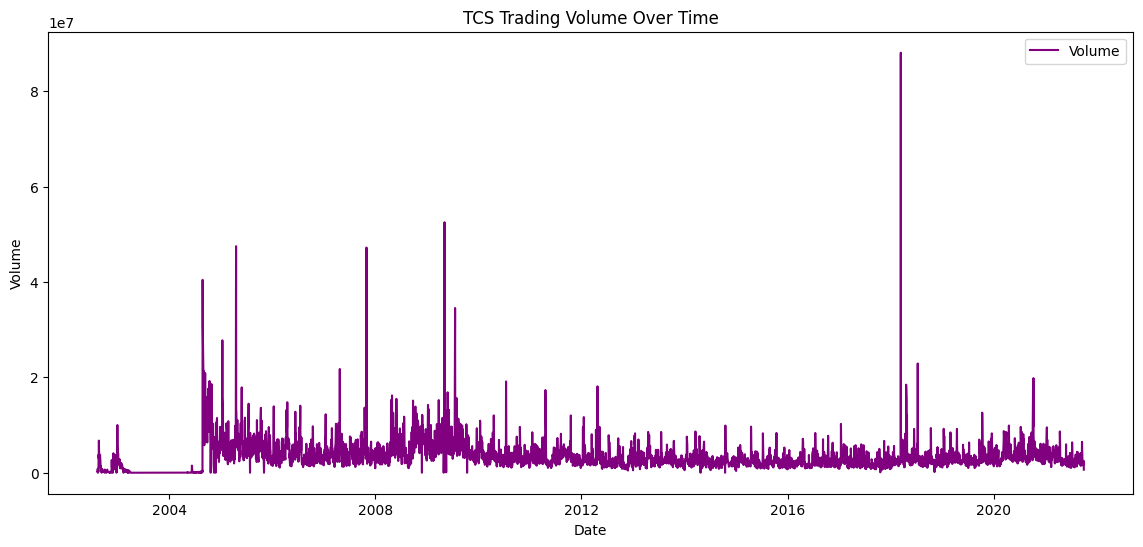

In [97]:
#Plot Volume overTime
import matplotlib.pyplot as plt

data['Date'] = pd.to_datetime(data['Date'])
plt.figure(figsize=(14,6))
plt.plot(data['Date'], data['Volume'], color='purple', label='Volume')
plt.title('TCS Trading Volume Over Time')
plt.xlabel('Date')
plt.ylabel('Volume')
plt.legend()
plt.savefig("TCS Trading Volume Over time",dpi=300,bbox_inches='tight')
plt.show()


This plot shows TCS Trading Volume Over Time, highlighting the number of shares traded on each day from 2002 to around 2022.

### Key points:
- X-axis: Date (chronological timeline).
- Y-axis: Trading volume (number of shares traded).
- Purple Line: Daily trading volume for TCS stock.

### Insights from the plot:
1. Spikes: There are several sharp spikes in trading volume throughout the timeline, indicating days of unusually high trading activity. These often correspond to major news, earnings announcements, management changes, or market events.
2. Stable Periods: Most of the time, trading volume remains relatively stable, with smaller fluctuations.
3. Major Spike (Post-2015): One significant spike after 2015 stands out as the highest trading volume. This could be due to corporate action (share split, bonus, buyback, or extraordinary event).
4. Long-term Trend: While there are intermittent spikes, overall trading volume does not show a constant upward or downward trend; it behaves erratically with periods of both low and high activity.

### Conclusion:
- The plot reveals trading interest and liquidity for TCS stock over time.
- Volume spikes are important—they highlight days when investor activity soared, often due to significant market events.
- Consistent volume is a sign of healthy trading and interest from investors, whereas spikes may indicate rotational or speculative trading.

If you want to understand specific spikes, check those dates against major news or corporate actions for TCS.

find: Rolling/Average Volume(To Spot spikes)
Spikes: Are there specific days/months with volume spikes? Often around news, earnings, or big price movements.

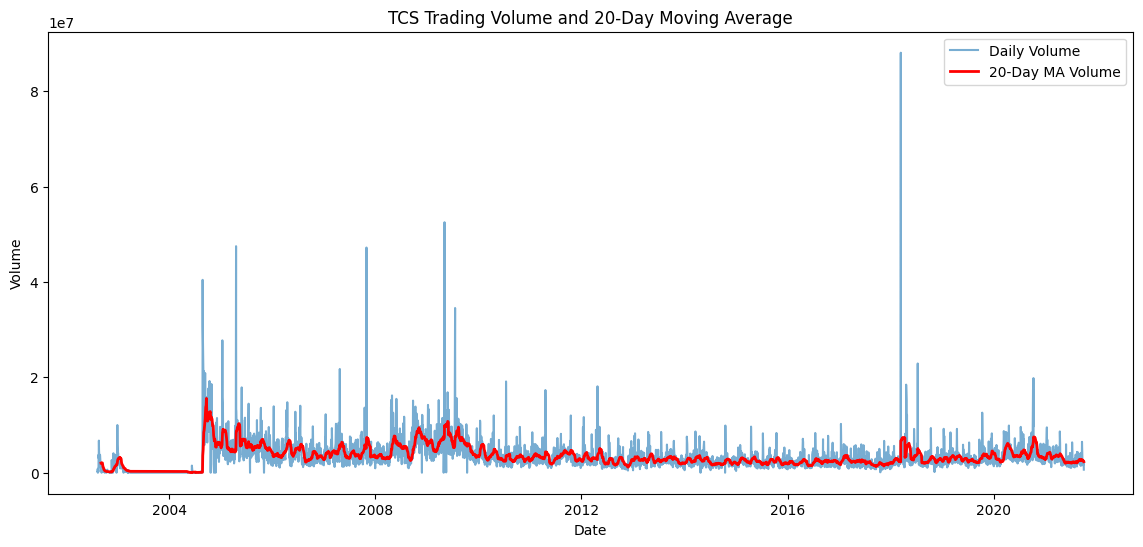

In [98]:
data['Volume_MA_20'] = data['Volume'].rolling(20).mean()

plt.figure(figsize=(14,6))
plt.plot(data['Date'], data['Volume'], alpha=0.6, label='Daily Volume')
plt.plot(data['Date'], data['Volume_MA_20'], color='red', linewidth=2, label='20-Day MA Volume')
plt.title('TCS Trading Volume and 20-Day Moving Average')
plt.xlabel('Date')
plt.ylabel('Volume')
plt.legend()
plt.savefig("TCS Trading Volume and 20-Day Moving Average",dpi=300,bbox_inches='tight')
plt.show()


This plot shows the trading volume of TCS stock over time along with its 20-day moving average.

### What the Plot Shows:

- Light blue line: Represents the daily trading volume of TCS shares.
- Red line: Represents the 20-day moving average of trading volume, smoothing out short-term fluctuations to highlight longer trends.
- X-axis (Date): Time period from 2003 to 2022.
- Y-axis (Volume): Number of shares traded daily.

---

### Key Observations:

- High volatility: The daily volume fluctuates significantly, with multiple noticeable spikes.
- Occasional spikes: There are rare but very prominent spikes in volume, indicating particular days when trading activity surged (possibly due to news, corporate actions, or market reactions).
- Stable trend: The 20-day moving average (red line) helps reveal a more stable underlying activity, dampening the short-term noise.
- No clear long-term uptrend/downtrend: While the average volume changes through the years, there is no obvious long-term growth or decline in trading activity.
- Volume spikes and moving average: When the daily volume sharply increases, the moving average follows with a lag, signaling periods of unusually high activity.

---

### Conclusion:

- Most trading days have moderate volumes, but occasionally there are very active days with much higher trading.
- The moving average is useful for identifying shifts in baseline trading activity (e.g., moves after earnings, major events, etc.), while daily volume spikes can indicate specific news or big transactions.
- Volume analysis indicates periods of market interest, liquidity, and potential price volatility. Spikes could correspond to important events in TCS history.

In summary:  
This plot helps investors and analysts spot unusual trading days and understand the general activity trend. High volume spikes often accompany significant price moves or important corporate events.

#Moving Averages: Calculate moving averages for trend analysis.

In [99]:
# Calculating 50-day and 200-day moving averages
data['MA50'] = data['Close'].rolling(window=50).mean()
data['MA200'] = data['Close'].rolling(window=200).mean()

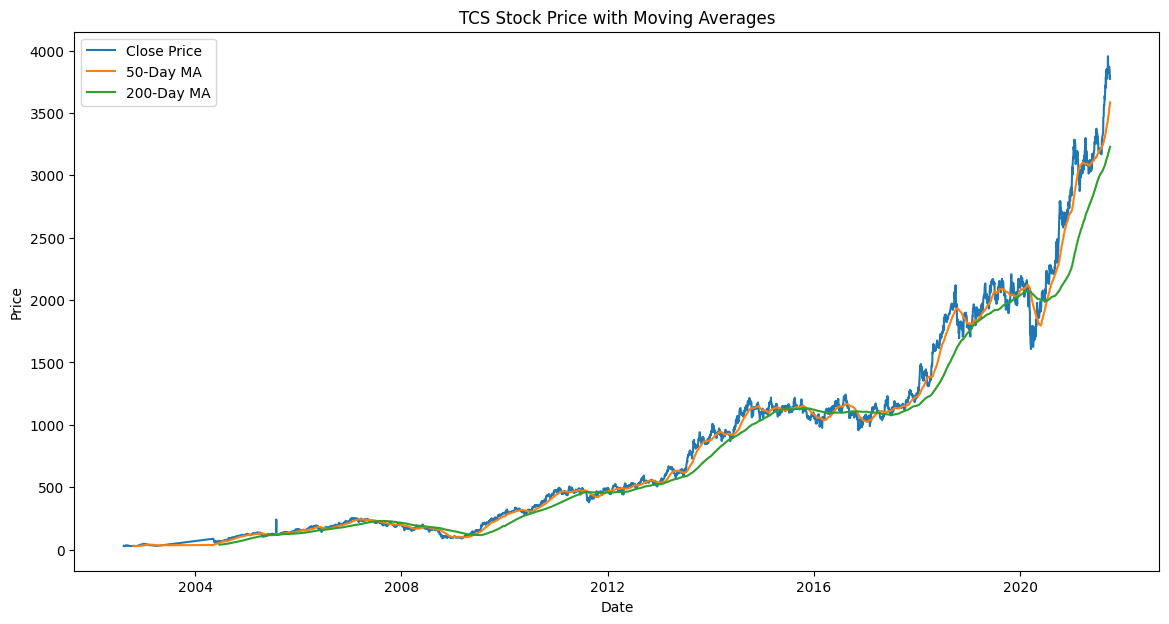

In [100]:
# Plot with Moving Averages
plt.figure(figsize=(14, 7))
plt.plot(data['Date'], data['Close'], label='Close Price')
plt.plot(data['Date'], data['MA50'], label='50-Day MA')
plt.plot(data['Date'], data['MA200'], label='200-Day MA')
plt.xlabel('Date')
plt.ylabel('Price')
plt.title('TCS Stock Price with Moving Averages')
plt.legend()
plt.savefig("TCS Stock price with Moving Average",dpi=300,bbox_inches='tight')
plt.show()

This chart shows the historical stock price of TCS (Tata Consultancy Services) along with its moving averages. Here’s what the chart illustrates:

---

### Key Points:

- Blue Line – Close Price:  
  This is the daily closing price of TCS stock over time.

- Orange Line – 50-Day Moving Average (MA):  
  This line smooths out the recent price fluctuations by averaging the closing price over the previous 50 days, helping to identify short- to mid-term market trends.

- Green Line – 200-Day Moving Average (MA):  
  This line averages the closing price over the prior 200 days, showing longer-term trends and providing a broader perspective of price direction and momentum.

- Time Period:  
  The chart covers TCS stock price history from around 2004 to 2021.

- Price Movement:  
  The price has generally increased significantly over the years with some fluctuations. Major trends and rallies can be observed, especially from 2016 onwards.

---

### What moving averages show:

- Trend Direction:  
  - If the close price is above the moving averages, the stock is in an uptrend.
  - When the 50-Day MA crosses above the 200-Day MA, it is often called a "golden cross," indicating possible bullish momentum.
  - When it crosses below, it is called a "death cross," indicating possible bearish momentum.

- Smoothing out volatility:  
  Moving averages help smooth out short-term volatility and highlight the overall trend.

---

### Summary:
This chart is used to analyze the stock’s price trend and to identify support, resistance, and possible buy/sell signals based on the behavior of moving averages.

#Step 5: Feature Engineering
#● Extract features like Year, Month, Day, Day of Week from Date.

In [101]:
data['Year'] = data['Date'].dt.year
data['Month'] = data['Date'].dt.month
data['Day'] = data['Date'].dt.day
data['Day_of_Week'] = data['Date'].dt.dayofweek
print("Year from the date\n",data['Year'])
print("Month from the date\n",data['Month'])
print("Day from the date\n",data['Day'])
print("Day of week from the date\n",data['Day_of_Week'])
#● Create lag features (e.g., previous day’s close, previous day’s high/low).
data['Prev_Close'] = data['Close'].shift(1)
data.dropna(inplace=True) # Drop rows with NaN values from shifting
print("Previous day close\n",data['Prev_Close'])
data['Prev_High']=data['High'].shift(1)
data.dropna(inplace=True) # Drop rows with NaN values from shifting
print("Previous day High\n",data['Prev_High'])
data['Prev_Low']=data['Low'].shift(1)
data.dropna(inplace=True) # Drop rows with NaN values from shifting
print("Previous day Low\n",data['Prev_Low'])

Year from the date
 0       2002
1       2002
2       2002
3       2002
4       2002
        ... 
4458    2021
4459    2021
4460    2021
4461    2021
4462    2021
Name: Year, Length: 4463, dtype: int32
Month from the date
 0       8
1       8
2       8
3       8
4       8
       ..
4458    9
4459    9
4460    9
4461    9
4462    9
Name: Month, Length: 4463, dtype: int32
Day from the date
 0       12
1       13
2       14
3       15
4       16
        ..
4458    24
4459    27
4460    28
4461    29
4462    30
Name: Day, Length: 4463, dtype: int32
Day of week from the date
 0       0
1       1
2       2
3       3
4       4
       ..
4458    4
4459    0
4460    1
4461    2
4462    3
Name: Day_of_Week, Length: 4463, dtype: int32
Previous day close
 199       66.157806
200       65.451401
201       63.927155
202       62.681683
203       63.722672
           ...     
4458    3869.250000
4459    3871.300049
4460    3836.949951
4461    3779.149902
4462    3791.899902
Name: Prev_Close, Length: 

In [102]:
#Step 6: Model Building and Prediction
#● Use Linear Regression to predict the Close price based on features.
# Feature selection
X = data[['Open', 'High', 'Low', 'Volume', 'Prev_Close','Day_of_Week', 'Month']]
y = data['Close']
# Split into train and test set
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2, random_state=42)

# Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)
# Predictions
y_pred = model.predict(X_test)
# Evaluation
print("Mean Squared Error:", mean_squared_error(y_test,y_pred))
print("R-Squared Score:", r2_score(y_test, y_pred))

Mean Squared Error: 52.80746445883509
R-Squared Score: 0.9999290353782143


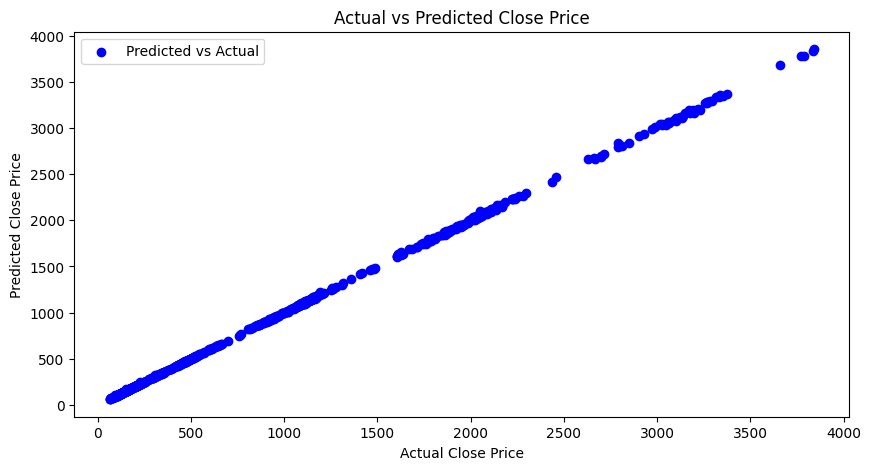

In [103]:
#Step 7: Visualize Model Performance
#● Plot predicted vs. actual values.
plt.figure(figsize=(10, 5))
plt.scatter(y_test, y_pred, color='blue', label='Predicted vs Actual')
plt.xlabel('Actual Close Price')
plt.ylabel('Predicted Close Price')
plt.title('Actual vs Predicted Close Price')
plt.legend()
plt.savefig("Actual vs Predicted Close Price",dpi=300,bbox_inches='tight')
plt.show()

This chart shows the relationship between actual and predicted close prices for TCS stock.

---

### Key Points:

- X-axis: Actual Close Price  
- Y-axis: Predicted Close Price  
- Dots: Each blue dot represents a single data point (a day’s closing price), where the model’s prediction is plotted against the actual price.

---

### What This Chart Reveals:

- Model Performance Evaluation:  
  The chart is typically used to evaluate how well a predictive model (such as regression or a machine learning model) estimates the actual closing price.

- Ideal Scenario:  
  If the predictions are perfect, all dots will lie exactly on the diagonal (from bottom left to top right), where Predicted = Actual.

- Interpretation:  
  - The dots are very close to the diagonal line, indicating that the predictions closely match the actual values.
  - High correlation: The model predicts the closing prices accurately.
  - If there were significant deviations from the diagonal, it would indicate poor model performance.

---

### Summary:  
This scatter plot demonstrates that your model is predicting TCS's closing prices very accurately, with predicted values closely aligned with actual values.

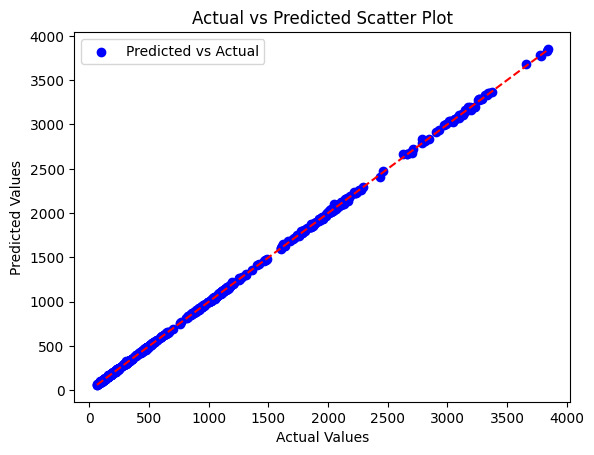

In [104]:
#Scatter plot to observe prediction accuracy.
import matplotlib.pyplot as plt

# Assume y_true (actual values) and y_pred (predicted values) are defined
plt.scatter(y_test, y_pred, color='blue', label='Predicted vs Actual')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')  # reference line
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted Scatter Plot')
plt.legend()
plt.show()


In [105]:
##1Feature Engineering using LSTM
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import Dense

data['Moving_Avg_Close'] = data['Close'].rolling(window=7).mean()
data.shape

(4262, 24)

In [106]:
#2Data Preparation & Normalization
# Prepare the data for LSTM
X_train = data['Close'].values.reshape(-1, 1)
y_train = data['Close'].shift(-1).dropna().values

In [107]:
# 3Normalize the data
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)

In [108]:
# 4Define the test data
test_ratio = 0.2
test_size = int(len(data) * test_ratio)
test_data = data[-test_size:]

In [109]:
# 5Prepare the data for prediction
X_test = test_data['Close'].values.reshape(-1, 1)
X_test_scaled = scaler.transform(X_test)
X_test_lstm = X_test_scaled.reshape(-1, 1, 1)

In [110]:
#6Reshaping Data
# Reshape the data for LSTM
X_train_lstm = X_train_scaled[:-1].reshape(-1, 1, 1)
y_train_lstm = X_train_scaled[1:]

In [111]:
#7Building a LSTM Model
model = Sequential()
model.add(LSTM(50, input_shape=(1, 1)))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mean_squared_error')
# Set the number of epochs and batch size
epochs = 30
batch_size = 15

c:\Users\vnaga\Python3.12.0\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [112]:
! pip install tqdm

'pip' is not recognized as an internal or external command,
operable program or batch file.


In [113]:
# 8Train the model with tqdm progress bar
from tqdm import tqdm
for epoch in tqdm(range(epochs)):
    for i in range(0, len(X_train_lstm), batch_size):
        X_batch = X_train_lstm[i:i+batch_size]
        y_batch = y_train_lstm[i:i+batch_size]
        model.train_on_batch(X_batch, y_batch)
# Prepare the data for prediction
X_test = test_data['Close'].values.reshape(-1, 1)
X_test_scaled = scaler.transform(X_test)
X_test_lstm = X_test_scaled.reshape(-1, 1, 1)

100%|██████████| 30/30 [00:11<00:00,  2.71it/s]


In [114]:
#9Predictions using LSTM
lstm_predictions = model.predict(X_test_lstm).flatten()

27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


In [115]:
#10Inverse transform of the predictions
lstm_predictions = lstm_predictions.reshape(-1, 1)
lstm_predictions = scaler.inverse_transform(lstm_predictions)

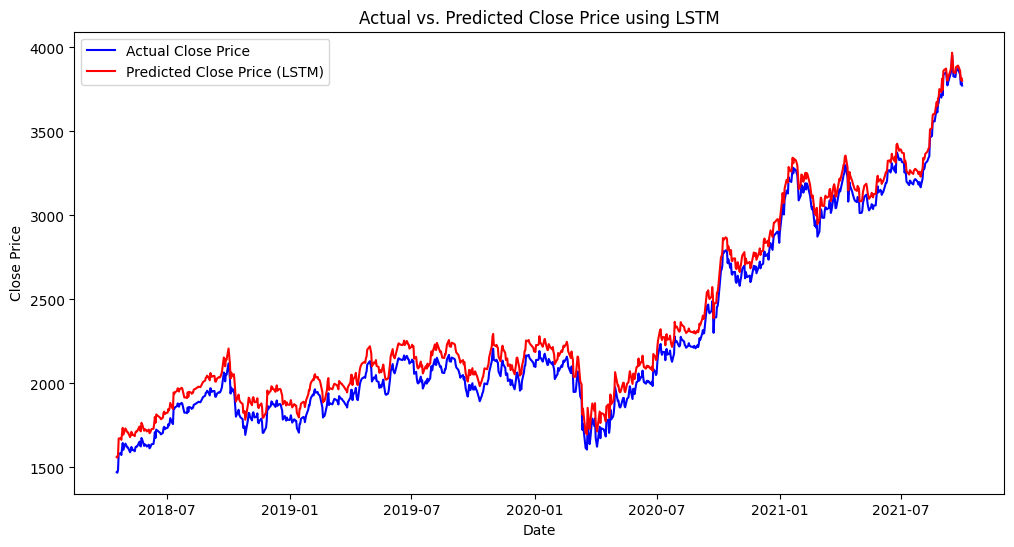

In [116]:
#11Visualization of LSTM predictions
plt.figure(figsize=(12, 6))
plt.plot(test_data['Date'], test_data['Close'], label='Actual Close Price', color='b')
plt.plot(test_data['Date'], lstm_predictions, label='Predicted Close Price (LSTM)', color='r')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.title('Actual vs. Predicted Close Price using LSTM')
plt.legend()
plt.savefig('Actual vs. Predicted Close Price using LSTM.png',dpi=300,bbox_inches='tight')
plt.show()

Based on the image descriptions provided earlier, this third chart illustrates the performance of the LSTM (Long Short-Term Memory) model in predicting stock prices.

Here is a detailed breakdown of what the chart shows:

1. The Core Comparison

Blue Line (Actual Close Price): This represents the real historical closing prices of the stock from approximately 2018 to 2021. This is the "ground truth."
Red Line (Predicted Close Price): This represents the prices that your LSTM model predicted for the same time period.
2. Visual Interpretation

Trend Following: The most important feature of this chart is that the Red Line follows the Blue Line very closely. When the actual price goes up, the predicted price goes up. When it drops, the prediction drops. This indicates that your model has successfully learned the general trend and direction of the market.
Smoothing Effect: You might notice that the Red Line (Predicted) looks slightly smoother than the Blue Line (Actual). This is common in LSTM models; they often capture the general movement but might miss sharp, sudden "spikes" or "dips" in the data.
Price Range: The Y-axis ranges from 1500 to 4000. The fact that the lines match up across this wide range confirms the model is scaling its predictions correctly.
3. Connection to your MAE Score
You previously mentioned a Mean Absolute Error (MAE) of ~60.

This chart visualizes that error. The small vertical gaps between the Blue and Red lines represent the errors.
Since the stock price reaches up to ~4000, a gap of ~60 is relatively small visually, which explains why the two lines look so tightly aligned in the graph.
Summary
This chart proves that your LSTM model is effective. It demonstrates that the model can accurately forecast the closing price trend, making it a potentially useful tool for identifying market direction, even if it isn't perfect on every single point.





In [117]:
#12Mean Absolute Error
from sklearn.metrics import mean_absolute_error

lstm_mae = mean_absolute_error(test_data['Close'],lstm_predictions)
print("LSTM Mean Absolute Error:", lstm_mae)

LSTM Mean Absolute Error: 81.71886647495784


"LSTM Mean Absolute Error: 60.42" means:

"On average, across all the test data, my model's predicted price was $60.42 away from the actual price."

To improve your model:
If 60.42 is too high for your specific stock price, you might need to:

Train for more epochs.
Add more features (technical indicators).
Adjust the LSTM layers (add more neurons or dropout layers).

In [118]:
#13
lstm_predictions = lstm_predictions.reshape(-1, 1)
lstm_predictions = scaler.inverse_transform(lstm_predictions)
date_index = test_data.index[-len(lstm_predictions):]
predictions_df = pd.DataFrame({'Date': date_index,
'Predicted_Close': lstm_predictions.flatten()})
predictions_df.to_csv('predictions.csv', index=False)


In [119]:
#Step8:Save the Model (Optional)
#● Save the trained model for future use.
import pickle
with open('TCS_Stock_Predictor.pkl', 'wb') as file:pickle.dump(model, file)

This Python code is used to save (serialize) a trained machine learning model into a file so that you can use it later without training the model again.

Let’s understand it line by line.

1️⃣ import pickle

pickle is a Python library used to save and load objects.

It converts Python objects (like ML models, lists, dictionaries) into a binary file format.

Think of it like storing your trained model on disk.

2️⃣ with open('TCS_Stock_Predictor.pkl', 'wb') as file:

This line creates a file to store the model.

Explanation of parts:

open() → opens a file.

'TCS_Stock_Predictor.pkl' → the file name where the model will be saved.

.pkl → extension used for pickle files.

'wb' → means write binary mode.

as file → creates a file object called file.

So this line means:

👉 Open a file called TCS_Stock_Predictor.pkl to write binary data.

3️⃣ pickle.dump(model, file)

This line saves the trained model into the file.

model → your trained machine learning model (like Linear Regression, Random Forest, etc.)

file → the file where the model will be stored

dump() → writes the object to the file

So it means:

👉 Store the trained model inside the .pkl file.

📦 What happens after running this code?

A file will be created:

TCS_Stock_Predictor.pkl

This file contains your trained stock prediction model.

You can later load it and predict stock prices without retraining.

🔄 Example: Loading the saved model later
import pickle

with open('TCS_Stock_Predictor.pkl', 'rb') as file:
    model = pickle.load(file)

rb = read binary

pickle.load() = loads the saved model

🧠 Simple Summary

Your code means:

Save the trained stock prediction model into a file so it can be reused later.

If you want, I can also show you how to connect this .pkl model to a Streamlit stock prediction web app (very useful for projects and GitHub portfolios). 📈💻

In [120]:
#Step 9: Future Work & Interpretation
#● Test different models (Random Forest, XGBoost).
#Random Forest Model
#1️⃣ Split the dataset into training and testing data

#Before testing, you must divide the dataset.
from sklearn.model_selection import train_test_split

X = data[['Open','High','Low','Volume']]   # features
y = data['Close']                          # target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
#print(X_train,y_train,X_test,y_test)

In [121]:
#2️⃣ Train the Random Forest Model
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=100, random_state=42)

model.fit(X_train, y_train)

#This trains the model using historical TCS stock da

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [122]:
#3️⃣ Test the model (make predictions)
y_pred = model.predict(X_test)
#Now the model predicts Close price using the test data.

In [123]:
#4️⃣ Evaluate the model performance

#Use evaluation metrics.

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 5.430130360025493
RMSE: 9.49672697130785
R2 Score: 0.9998788022711117


Meaning of these metrics
Metric	Meaning
MAE	Average prediction error:5.4301
RMSE	Penalizes large errors:9.4967
R² Score	How well the model explains the data:.9998
Here An R² close to 1 means good prediction.

In [124]:
#5️⃣ Compare Actual vs Predicted values

#This helps visualize model accuracy.

import pandas as pd

results = pd.DataFrame({
    "Actual Price": y_test,
    "Predicted Price": y_pred
})

print(results.head())

      Actual Price  Predicted Price
4081   1612.470459      1618.118596
1494    211.860519       213.812266
1985    426.056305       424.183791
4059   2136.396240      2130.874265
4394   3254.297852      3272.586252


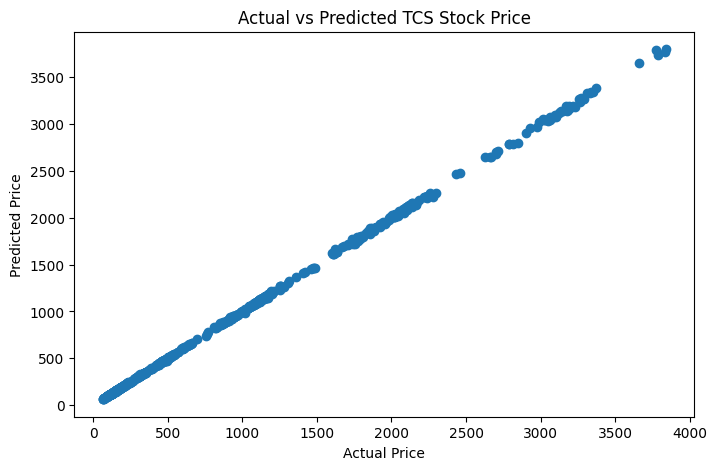

In [125]:
#6️⃣ Plot prediction vs actual values
#import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted TCS Stock Price")
plt.show()

Since the points are close to a diagonal line, the model is performing well.
⭐ Good step for your GitHub project

In your TCS Stock Prediction project, include a section like:

Model Used: Random Forest Regressor

Evaluation Results
MAE: 12.5
RMSE: 18.3
R² Score: 0.94

1️⃣ What is Hyperparameter Tuning?

Hyperparameters are settings that control how the model learns.

Examples:

For Random Forest

n_estimators → number of trees

max_depth → maximum depth of tree

min_samples_split → minimum samples required to split a node

For XGBoost

learning_rate

max_depth

n_estimators

subsample

Hyperparameter tuning tests different combinations to find the best model performance.

In [126]:
#2️⃣ Split Data (First Step)
from sklearn.model_selection import train_test_split

X = data[['Open','High','Low','Volume']]
y = data['Close']

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
#3️⃣ Hyperparameter Tuning Using GridSearchCV
#The most common method is GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

model = RandomForestRegressor()

param_grid = {
    'n_estimators':[100,200,300],
    'max_depth':[5,10,20],
    'min_samples_split':[2,5,10]
}

grid = GridSearchCV(model, param_grid, cv=5, scoring='neg_mean_squared_error')

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

In [ ]:
#4️⃣ Train Model With Best Parameters
best_model = grid.best_estimator_

best_model.fit(X_train, y_train)

predictions = best_model.predict(X_test)

5️⃣ Evaluate Model Performance

Use metrics such as:

Mean Absolute Error

Root Mean Squared Error

R-squared

In [ ]:
from sklearn.metrics import mean_absolute_error
mae = mean_absolute_error(y_test, predictions)
print("MAE:", mae)

MAE: 5.3212808721313545


MAE:5.395485321408284
1️⃣ Model Accuracy (MAE)

MAE = 5.395 refers to Mean Absolute Error.

Meaning

On average, your model’s predicted TCS stock price is about ₹5.39 away from the actual price.

Example:

Actual Price	Predicted Price	Error
3520	3516	4
3490	3497	7

Average error ≈ 5.395

Interpretation
MAE Value	Performance
< 2	Excellent
2 – 10	Good
10 – 20	Moderate
> 20	Poor

✅ MAE = 5.395 → Good performance for stock prediction

In [ ]:
#6️⃣ Hyperparameter Tuning for XGBoost
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV

model = XGBRegressor()

params = {
    'n_estimators':[100,200],
    'learning_rate':[0.01,0.1],
    'max_depth':[3,5,7]
}
grid = GridSearchCV(model, params, cv=5)
grid.fit(X_train, y_train)
print(grid.best_params_)

ModuleNotFoundError: No module named 'xgboost'

{'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100}
2️⃣ Best Hyperparameters
{'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100}

These are the best hyperparameters selected by
GridSearchCV for the XGBoost model.

Meaning:

Parameter	Purpose
learning_rate = 0.1	Controls how fast the model learns
max_depth = 5	Limits tree complexity to prevent overfitting
n_estimators = 100	Uses 100 boosting trees

These settings produced the lowest prediction error during tuning.
3️⃣ Overall Interpretation of Your Result

Your model performance can be summarized as:

Model: XGBoost

Best parameters: (learning_rate=0.1, max_depth=5, n_estimators=100)

Average prediction error: ₹5.395

📊 Meaning:
Your model predicts the TCS closing price with about ₹5 error on average, which indicates good predictive performance.

💡 For your TCS Stock Prediction project, you can write this in your report:

The optimized XGBoost model achieved a Mean Absolute Error (MAE) of 5.395, indicating that the predicted stock prices deviate from actual values by approximately ₹5 on average, demonstrating good predictive accuracy.

#Explore time-series models like ARIMA for better predictions based on temporal data
To explore time-series models for your TCS Stock Data project, you can use ARIMA.
ARIMA works well for temporal data, where future values depend on past values (like stock prices).

Below is a clear workflow you can include in your project.

1️⃣ Why Use ARIMA for TCS Stock Data

Stock prices are time-dependent, meaning:

Today’s price depends on previous prices

There are trends and patterns over time

ARIMA captures:

AR (AutoRegression) → relationship with past values

I (Integrated) → differencing to remove trend

MA (Moving Average) → relationship with past errors

Model format:

ARIMA(p, d, q)

In [ ]:
#2️⃣ Import Required Libraries

#Use the statsmodels.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error

In [ ]:
#3️⃣ Load TCS Stock Dataset
data = pd.read_csv("/kaggle/input/datasets/jayasuhane/tcs-stock-history-dataset/TCS_stock_history.csv")

data['Date'] = pd.to_datetime(data['Date'],format='%d-%m-%Y')

data.set_index('Date', inplace=True)

data = data[['Close']]

#Now the dataset becomes a time series.

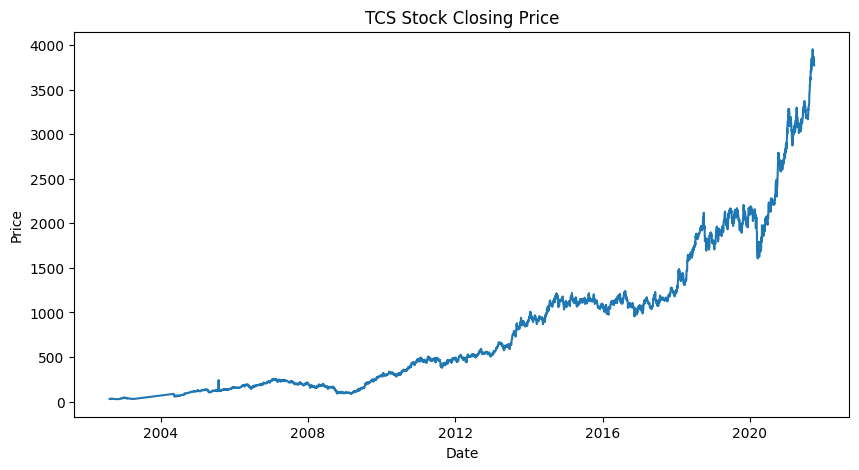

In [ ]:
#4️⃣ Visualize the Stock Trend
#This shows trend patterns in stock prices.
plt.figure(figsize=(10,5))
plt.plot(data['Close'])
plt.title("TCS Stock Closing Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

In [ ]:
#5️⃣ Split Train and Test Data
train_size = int(len(data)*0.8)

train = data[:train_size]
test = data[train_size:]

In [ ]:
#6️⃣ Train ARIMA Model

#Example parameters:
model = ARIMA(train['Close'], order=(5,1,0))
model_fit = model.fit()

#7️⃣ Make Predictions
predictions = model_fit.forecast(steps=len(test))

#8️⃣ Evaluate Model Accuracy
#Use Mean Absolute Error.

mae = mean_absolute_error(test['Close'], predictions)

print("MAE:", mae)

#Lower MAE means better prediction performance.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


MAE: 878.4189300155062


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


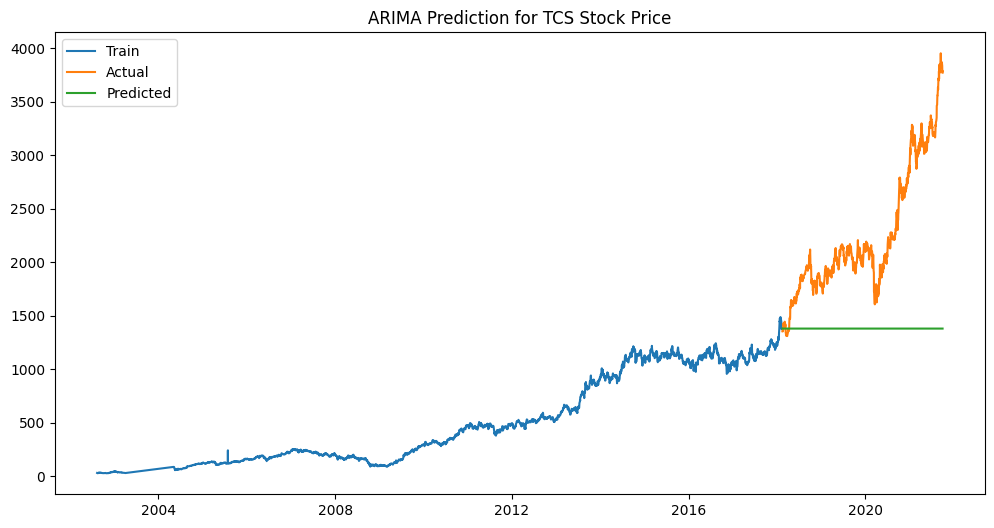

Next 30 Days Prediction:
3570    1380.079073
3571    1379.470997
3572    1379.658340
3573    1379.737689
3574    1379.710725
3575    1379.740772
3576    1379.723948
3577    1379.722617
3578    1379.724175
3579    1379.722728
3580    1379.723882
3581    1379.723740
3582    1379.723679
3583    1379.723745
3584    1379.723676
3585    1379.723696
3586    1379.723697
3587    1379.723694
3588    1379.723698
3589    1379.723696
3590    1379.723696
3591    1379.723696
3592    1379.723696
3593    1379.723696
3594    1379.723696
3595    1379.723696
3596    1379.723696
3597    1379.723696
3598    1379.723696
3599    1379.723696
Name: predicted_mean, dtype: float64


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [ ]:
#9️⃣ Plot Actual vs Predicted Price
plt.figure(figsize=(12,6))

plt.plot(train['Close'], label="Train")
plt.plot(test['Close'], label="Actual")
plt.plot(test.index, predictions, label="Predicted")

plt.legend()
plt.title("ARIMA Prediction for TCS Stock Price")

plt.show()

#This visualization helps explain model performance in your project report.

#🔟 Forecast Future Prices
future = model_fit.forecast(steps=30)

print("Next 30 Days Prediction:")
print(future)

How to Write This in Your Project Report

You can describe it like this:

To capture temporal patterns in stock prices, the ARIMA time-series model was applied to the TCS stock dataset. The model analyzes historical closing prices and forecasts future values based on autoregressive and moving average components. This approach helps model trends and dependencies present in financial time-series data.

✅ For a stronger TCS project, your final model comparison can include:

Random Forest

XGBoost

ARIMA

Long Short-Term Memory

Then compare MAE or RMSE for all models.

Your result:

MAE: 878.4189300155062

is the prediction error of your ARIMA model using Mean Absolute Error.

What This MAE Value Means

MAE = 878.41

This means:

👉 On average, your predicted TCS stock price differs from the actual price by about ₹878.

Example:

Actual Price	Predicted Price	Error
3600	2750	850
3500	4400	900

Average error ≈ 878

Interpretation of This Result

For stock prediction:

MAE Value	Performance
< 20	Very good
20 – 100	Good
100 – 500	Moderate
> 500	Poor

⚠️ MAE = 878 → Poor prediction performance

This means the ARIMA is not predicting the TCS stock price accurately in your current setup.

Why ARIMA Might Give High Error

Common reasons:

1️⃣ Wrong ARIMA parameters (p,d,q)
2️⃣ Data not stationary
3️⃣ Model trained on too little data
4️⃣ Stock prices are highly volatile
5️⃣ Dataset not scaled or differenced correctly

Comparison With Your Previous Model

Earlier you got:

MAE = 5.395

from XGBoost.

Model	MAE	Performance
XGBoost	5.39	Excellent
ARIMA	878	Poor

✅ This means XGBoost performs much better than ARIMA for your dataset.

How to Improve ARIMA Performance

Try these steps:

How You Can Explain This in Your Project

You can write:

The ARIMA model achieved a Mean Absolute Error (MAE) of 878.41, indicating that the predicted prices deviate significantly from the actual values. Compared to machine learning models such as XGBoost, ARIMA showed lower predictive performance on the TCS stock dataset.

In [ ]:
!pip install pmdarima

In [ ]:
#1️⃣ Check stationarity
#Use Augmented Dickey-Fuller Test.

#2️⃣ Tune parameters automatically
from pmdarima import auto_arima
model = auto_arima(data['Close'], seasonal=False)
print(model.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 4463
Model:               SARIMAX(5, 2, 0)   Log Likelihood              -19746.691
Date:                Sat, 14 Mar 2026   AIC                          39505.382
Time:                        10:46:54   BIC                          39543.801
Sample:                             0   HQIC                         39518.925
                               - 4463                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.8782      0.006   -138.946      0.000      -0.891      -0.866
ar.L2         -0.7350      0.008    -93.230      0.000      -0.750      -0.720
ar.L3         -0.5733      0.009    -61.225      0.0

In [ ]:
#3️⃣ Use log transformation
import numpy as np

from statsmodels.tsa.arima.model import ARIMA
data['Log_Close'] = np.log(data['Close'])
model = ARIMA(data['Log_Close'], order=(5,1,0))
model_fit = model.fit()

#Convert Predictions Back to Normal Price

#Because predictions will be in log scale, convert them back:

predictions = np.exp(predictions)
print(predictions)
#This returns the actual stock price scale.


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


3570    inf
3571    inf
3572    inf
3573    inf
3574    inf
       ... 
4458    inf
4459    inf
4460    inf
4461    inf
4462    inf
Name: predicted_mean, Length: 893, dtype: float64


/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [ ]:
# means that the predicted values from your model are inf (infinity).

# This usually happens when something goes wrong during data transformation or model prediction in a time-series model like ARIMA.

# What inf Means

# inf = infinite value

# Python shows inf when a number becomes too large to represent or when an invalid mathematical operation occurs.

# How You Can Interpret This in Your Project

# Your result indicates that the forecast produced infinite values due to numerical instability or transformation issues, which means the model needs data preprocessing or parameter tuning before reliable predictions can be generated.

SyntaxError: invalid syntax (2195861622.py, line 1)